# Proyecto Final · Módulo 4  
## Estadística y Probabilidad para Data Science orientada a Machine Learning

## Información general del proyecto

| Campo | Completar |
|---|---|
| Nombre del proyecto | Descuentos, precio y rentabilidad en un e-commerce: análisis estadístico de 397,569 líneas de pedido |
| Nombre del dataset | E-Commerce Sales Analytics Dataset (tablas `order_items` y `product_catalog`) |
| Fuente del dataset | Kaggle |
| Link del dataset | https://www.kaggle.com/datasets/datascikhan/e-commerce-sales-and-customer-analytics |
| Link del video de defensa | nan |
| Fecha de entrega | 4/10/2026 |
| Profesor | Braulio Javier Díaz Ortiz |
| Grupo | Grupo # |

---

## Integrantes

| Nombre | Matrícula / ID | 
|---|---|
| Richard Feliciano | 20741 | 
| Johan Mercedes Dotel| 21796| 
| Yelitza Santana Rivas | 21807|


# 1. Introducción

**¿Cuál es el tema del dataset?**  
El dataset pertenece a un negocio de e-commerce. Para este proyecto se usan dos de sus tablas: `order_items` (397,569 líneas de pedido con cantidad, precio, descuento, impuestos, envío, costo y ganancia) y `product_catalog` (1,175 productos con categoría, subcategoría, marca, proveedor y calificación). Unidas, permiten estudiar el desempeño comercial a nivel de línea de pedido, producto, categoría, marca y proveedor.

**¿Por qué elegimos este tema?**  
Porque conecta directamente precio, descuento, costo y ganancia, que son las decisiones más críticas de un negocio de retail, y porque el dataset combina variables numéricas y categóricas suficientes para aplicar todo el flujo estadístico del módulo (intervalos de confianza, pruebas de hipótesis, correlación, regresión y análisis de residuos) sobre datos con estructura de negocio real.

**¿Qué importancia tiene analizar esta problemática?**  
Saber si el descuento erosiona la ganancia, y si algunas categorías o proveedores son sistemáticamente más rentables, sustenta decisiones de pricing, surtido y negociación con proveedores. Mirar solo ventas totales puede llevar a premiar productos que venden mucho pero generan poco valor, o incluso pérdidas.

**¿Qué esperamos descubrir o comprender?**  
a) Si el porcentaje de descuento se relaciona de forma significativa con la ganancia por línea de pedido; 

b) si la rentabilidad difiere entre categorías; 

c) si la calificación del producto se asocia con el volumen comprado; 

d) si el proveedor influye en el costo de envío; y 

e) qué variables sirven como predictores de la ganancia para un futuro modelo de Machine Learning.

# 2. Planteamiento de la problemática

**1. Contexto del problema.**  
El negocio vende 1,175 productos en 15 categorías, con 10 proveedores y 144 marcas. Cada línea de pedido lleva un descuento que va de 0% hasta 60%, un costo de envío, impuestos y una ganancia que puede ser **negativa** (mínimo observado: −1,260.28). No toda venta es rentable, y no está claro a partir de qué punto el descuento empieza a destruir valor.

**2. Población o fenómeno analizado.**  
La unidad de análisis es la **línea de pedido** (397,569 registros, pertenecientes a 138,116 órdenes y 1,175 productos). El fenómeno estudiado es la relación entre las decisiones de precio y descuento y el resultado financiero de cada línea, según los atributos del producto (categoría, proveedor, calificación).

**3. Variables principales.**  
- Numéricas: `unit_price`, `discount_percentage`, `discount_amount`, `gross_sales`, `tax_amount`, `shipping_cost`, `net_sales`, `product_cost_total`, `product_cost`, `product_rating`, `quantity`, `profit` (variable objetivo).  
- Categóricas: `product_category`, `product_subcategory`, `brand`, `supplier`.

**4. Importancia del análisis.**  
Permite pasar de "¿cuánto vendimos?" a "¿qué venta realmente genera valor?", separando categorías y niveles de descuento que aportan ganancia de aquellos que la erosionan.

**5. Posibles decisiones apoyadas en los resultados.**  
- Fijar topes de descuento por categoría.  
- Priorizar inventario y marketing hacia categorías más rentables.  
- Revisar condiciones con proveedores según su impacto en costos.  
- Construir un modelo predictivo de ganancia por línea para apoyar decisiones de pricing.

# 3. Objetivo general y objetivos específicos

## Objetivo general

Analizar estadísticamente la relación entre el precio, el descuento, el costo y los atributos del producto con la ganancia generada por línea de pedido, para identificar los factores que más influyen en la rentabilidad de un negocio de e-commerce.

## Objetivos específicos

1. Determinar si existe una relación estadísticamente significativa entre el porcentaje de descuento y la ganancia por línea de pedido.
2. Comparar la ganancia promedio entre categorías de producto para identificar diferencias de rentabilidad.
3. Evaluar si la calificación del producto (`product_rating`) se asocia con la cantidad comprada por línea.
4. Construir un modelo de regresión lineal simple que explique la ganancia en función del precio unitario y evaluar su capacidad predictiva y sus residuos.
5. Explorar si el proveedor y la categoría se asocian con variables operativas y comerciales (costo de envío, nivel de descuento).

# 4. Descripción del dataset

| Elemento | Respuesta |
|---|---|
| Fuente del dataset | Kaggle: *E-Commerce Sales Analytics Dataset* (2021–2025). Se usan solo `order_items.csv` y `product_catalog.csv`. |
| Cantidad de filas | 397,569 (después de unir ambas tablas; el catálogo original tiene 1,175 filas) |
| Cantidad de columnas | 19 en la tabla unida y depurada (12 de `order_items` + 8 nuevas del catálogo - 1 duplicada) |
| Unidad de observación | Una línea de pedido (un producto dentro de una orden) |
| Variable objetivo, si aplica | `profit` (ganancia por línea de pedido) |
| Variables numéricas principales | `quantity`, `unit_price`, `discount_percentage`, `discount_amount`, `gross_sales`, `tax_amount`, `shipping_cost`, `net_sales`, `product_cost_total`, `product_cost`, `product_rating`, `profit` |
| Variables categóricas principales | `product_category` (15), `product_subcategory` (117), `brand` (144), `supplier` (10) |

## Diccionario de variables principales

| Variable | Tipo | Descripción | Uso en el análisis |
|---|---|---|---|
| `order_id` | Categórica (ID) | Identificador de la orden | Agrupación de líneas |
| `product_id` | Categórica (ID) | Identificador del producto (llave de unión) | Unión de tablas |
| `quantity` | Numérica discreta (1–5) | Unidades compradas en la línea | Hipótesis 3, EDA |
| `unit_price` | Numérica continua | Precio unitario de catálogo | Predictor en regresión, H5 |
| `discount_percentage` | Numérica continua (0–0.60) | Fracción de descuento aplicada | H1, EDA |
| `discount_amount` | Numérica continua | Monto del descuento | Correlación |
| `gross_sales` | Numérica continua | `quantity × unit_price` | Correlación |
| `tax_amount` | Numérica continua | Impuesto de la línea | Correlación |
| `shipping_cost` | Numérica continua | Costo de envío de la línea | H4 |
| `net_sales` | Numérica continua | Venta neta (`gross − descuento + impuesto + envío`) | Correlación |
| `product_cost_total` | Numérica continua | Costo total de la línea (`quantity × costo unitario`) | Correlación |
| `product_cost` | Numérica continua | Costo unitario del catálogo | Correlación |
| `profit` | Numérica continua | Ganancia de la línea (`net_sales − shipping_cost − product_cost_total`) | Variable objetivo |
| `product_category` | Categórica (15) | Categoría del producto | H2|
| `product_subcategory` | Categórica (117) | Subcategoría | Descriptivo |
| `brand` | Categórica (144) | Marca | Descriptivo |
| `supplier` | Categórica (10) | Proveedor | H4 |
| `product_rating` | Numérica continua (2.5–4.9) | Calificación promedio del producto | H3 |

# 5. Carga de datos y revisión inicial

## Extraccion y carga de DT

In [23]:
# Importar librerías necesarias para el análisis de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [24]:
# Definir rutas de los archivos CSV y cargar los datos
RUTA = {
    "order_items": "../data/raw/order_items.csv",
    "product_catalog": "../data/raw/product_catalog.csv"
    }
    
order_items = pd.read_csv(RUTA["order_items"])
product_catalog =pd.read_csv(RUTA["product_catalog"])

In [25]:
# Unir los datos de order_items y product_catalog y reorganizar las columnas
df_limpio = pd.merge(order_items, product_catalog, on='product_id', how='left')

cols_original = df_limpio.columns.tolist()

# Nuevo orden de las columnas
nuevo_orden = [
    'order_id','product_id','product_name','product_category',
    'product_subcategory','brand','supplier'
] + [c for c in cols_original if c not in [
    'order_id','product_id','product_name','product_category',
    'product_subcategory','brand','supplier'
]]

df_limpio = df_limpio[nuevo_orden]

print(df_limpio.columns.tolist())

['order_id', 'product_id', 'product_name', 'product_category', 'product_subcategory', 'brand', 'supplier', 'quantity', 'unit_price_x', 'discount_percentage', 'discount_amount', 'gross_sales', 'tax_amount', 'shipping_cost', 'net_sales', 'product_cost_x', 'profit', 'unit_price_y', 'product_cost_y', 'product_rating']


## Revision de datos

In [26]:
df_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 397569 entries, 0 to 397568
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             397569 non-null  str    
 1   product_id           397569 non-null  str    
 2   product_name         397569 non-null  str    
 3   product_category     397569 non-null  str    
 4   product_subcategory  397569 non-null  str    
 5   brand                397569 non-null  str    
 6   supplier             397569 non-null  str    
 7   quantity             397569 non-null  int64  
 8   unit_price_x         397569 non-null  float64
 9   discount_percentage  397569 non-null  float64
 10  discount_amount      397569 non-null  float64
 11  gross_sales          397569 non-null  float64
 12  tax_amount           397569 non-null  float64
 13  shipping_cost        397569 non-null  float64
 14  net_sales            397569 non-null  float64
 15  product_cost_x       397569 

In [27]:
df_limpio.isnull().sum()

order_id               0
product_id             0
product_name           0
product_category       0
product_subcategory    0
brand                  0
supplier               0
quantity               0
unit_price_x           0
discount_percentage    0
discount_amount        0
gross_sales            0
tax_amount             0
shipping_cost          0
net_sales              0
product_cost_x         0
profit                 0
unit_price_y           0
product_cost_y         0
product_rating         0
dtype: int64

In [28]:
df_limpio.shape

(397569, 20)

In [29]:
df_limpio.duplicated().sum()

np.int64(0)

In [30]:
df_limpio.dtypes

order_id                   str
product_id                 str
product_name               str
product_category           str
product_subcategory        str
brand                      str
supplier                   str
quantity                 int64
unit_price_x           float64
discount_percentage    float64
discount_amount        float64
gross_sales            float64
tax_amount             float64
shipping_cost          float64
net_sales              float64
product_cost_x         float64
profit                 float64
unit_price_y           float64
product_cost_y         float64
product_rating         float64
dtype: object

In [31]:
# Informe de tipos de datos, valores faltantes y duplicados
print("\n--- Informe de order_items y product_catalog ---\n")
print("Tipos order_items:\n", order_items.dtypes, "\n")
print("Tipos product_catalog:\n", product_catalog.dtypes, "\n")
print("Nulos order_items:", order_items.isnull().sum().sum())
print("Nulos product_catalog:", product_catalog.isnull().sum().sum())
print("Filas duplicadas order_items:", order_items.duplicated().sum())
print("Filas duplicadas product_catalog:", product_catalog.duplicated().sum())
print("product_id duplicados en catálogo:", product_catalog["product_id"].duplicated().sum())
print("Pares (order_id, product_id) repetidos:", order_items.duplicated(["order_id", "product_id"]).sum())
print("Órdenes únicas:", order_items["order_id"].nunique())


--- Informe de order_items y product_catalog ---

Tipos order_items:
 order_id                   str
product_id                 str
quantity                 int64
unit_price             float64
discount_percentage    float64
discount_amount        float64
gross_sales            float64
tax_amount             float64
shipping_cost          float64
net_sales              float64
product_cost           float64
profit                 float64
dtype: object 

Tipos product_catalog:
 product_id                 str
product_name               str
product_category           str
product_subcategory        str
brand                      str
supplier                   str
unit_price             float64
product_cost           float64
product_rating         float64
dtype: object 

Nulos order_items: 0
Nulos product_catalog: 0
Filas duplicadas order_items: 0
Filas duplicadas product_catalog: 0
product_id duplicados en catálogo: 0
Pares (order_id, product_id) repetidos: 87
Órdenes únicas: 138116


**Interpretación**  
`order_items` Tiene 397,569 filas y 12 columnas; `product_catalog` tiene 1,175 filas y 9 columnas. No hay valores faltantes ni filas completamente duplicadas, y `product_id` es único en el catálogo, por lo que la unión no multiplicará filas. Existen 87 pares (`order_id`, `product_id`) repetidos, pero en cada caso la cantidad y el descuento son distintos, así que se tratan como líneas legítimas distintas y **no** se eliminan. El dataset no contiene fechas, por lo que no es posible analizar estacionalidad.

## Interpretacion de los datos

### Comparación de columnas duplicadas (`_x` / `_y`)

Al unir `order_items` con `product_catalog` aparecieron columnas repetidas (`unit_price_x/_y`, `product_cost_x/_y`). Antes de decidir qué hacer con ellas, se verifica si son realmente iguales o si una depende de la otra.

In [32]:
print("\nComparación de precios unitarios:")
print("-" * 40)
print((df_limpio["unit_price_x"] == df_limpio["unit_price_y"]).value_counts()) # True    397569

print("\nComparación de costos de producto:")
print("-" * 40)
print((df_limpio["product_cost_x"] == df_limpio["product_cost_y"]).value_counts()) # False    231956 | True     165613
                                                                                   # Conclusión: no son columnas duplicadas.


Comparación de precios unitarios:
----------------------------------------
True    397569
Name: count, dtype: int64

Comparación de costos de producto:
----------------------------------------
False    231956
True     165613
Name: count, dtype: int64


In [33]:
print("\nComparación de costos de producto (detalle):")
print("-" * 50)
print((df_limpio["product_cost_x"] == df_limpio["product_cost_y"]))
print(
    (df_limpio["product_cost_x"] == df_limpio["product_cost_y"])
    .value_counts()
)


Comparación de costos de producto (detalle):
--------------------------------------------------
0         False
1         False
2         False
3         False
4         False
          ...  
397564    False
397565    False
397566    False
397567     True
397568    False
Length: 397569, dtype: bool
False    231956
True     165613
Name: count, dtype: int64


In [34]:
# Comprobar si product_cost_x depende de quantity
print("Relación entre costo y cantidad:")
print("-" * 40)

print(
    (
        df_limpio["product_cost_x"]
        ==
        df_limpio["product_cost_y"] * df_limpio["quantity"]
    ).value_counts()
)
# Aparecen algunos False debido a la precisión de los números float
# True     368799
# False     28770

Relación entre costo y cantidad:
----------------------------------------
True     368799
False     28770
Name: count, dtype: int64


In [35]:
# Repetir la comprobación usando tolerancia numérica
comparacion = np.isclose(
    df_limpio["product_cost_x"],
    df_limpio["product_cost_y"] * df_limpio["quantity"]
)

print(pd.Series(comparacion).value_counts())
# Pues sí, la relación se cumple para todas las filas considerando pequeñas diferencias de precisión numérica.
# True    397569
# Name: count, dtype: int64


True    397569
Name: count, dtype: int64


In [36]:
# Verificar una fila manualmente
num_fila = 0

print("Verificación manual de la fila")
print("=" * 75)
print(df_limpio.loc[num_fila])
print("=" * 75)

print(df_limpio.columns.tolist())
print("-" * 75)

fila = df_limpio.loc[num_fila]

print("quantity:", fila["quantity"])
print("product_cost_x:", fila["product_cost_x"])
print("product_cost_y:", fila["product_cost_y"])

print(
    "product_cost_y * quantity:",
    fila["product_cost_y"] * fila["quantity"]
)

Verificación manual de la fila
order_id                                                      ORD-301242
product_id                                                   PROD-000738
product_name           Garmin Total client-driven task-force Medical ...
product_category                                       Health & Wellness
product_subcategory                                      Medical Devices
brand                                                             Garmin
supplier                                                  Euro Logistics
quantity                                                               2
unit_price_x                                                       244.4
discount_percentage                                             0.339607
discount_amount                                                    166.0
gross_sales                                                        488.8
tax_amount                                                          22.6
shipping_cost       

### Filas duplicadas por combinación pedido + producto

In [37]:
# Cuenta las filas donde se repite la combinación pedido + producto.
# No significa que sean filas completamente duplicadas.
duplicados = df_limpio.duplicated(["order_id", "product_id"]).sum()

print("Duplicados order_id + product_id:", duplicados)


filas_repetidas = df_limpio.duplicated(
    ["order_id", "product_id"],
    keep=False
).sum()

print("Filas involucradas en repeticiones:", filas_repetidas)

# Selecciona todas las filas donde se repite pedido + producto.
ejemplos = df_limpio[
    df_limpio.duplicated(["order_id", "product_id"], keep=False) # keep=False permite mostrar todas las filas de cada repetición.
].sort_values(["order_id", "product_id"])

# Muestrar los primeros 10 ejemplos.
ejemplos[
    [
        "order_id",
        "product_id",
        "product_name",
        "quantity",
        "unit_price_x",
        "discount_percentage",
        "gross_sales",
        "profit"
    ]
].head(10)


Duplicados order_id + product_id: 87
Filas involucradas en repeticiones: 174


,order_id,product_id,product_name,quantity,unit_price_x,discount_percentage,gross_sales,profit
292639,ORD-116240,PROD-001079,General Mills Triple-buffered client-server wo...,4,42.15,0.043355,168.60,120.54
364770,ORD-116240,PROD-001079,General Mills Triple-buffered client-server wo...,1,42.15,0.123642,42.15,26.52
101373,ORD-124215,PROD-000044,LG Stand-alone logistical circuit Smart Watches,4,863.97,0.144428,3455.88,1147.28
138789,ORD-124215,PROD-000044,LG Stand-alone logistical circuit Smart Watches,1,863.97,0.096381,863.97,424.92
295982,ORD-135029,PROD-000354,Walmart Virtual intangible portal Decor,2,256.59,0.160479,513.18,160.67
393368,ORD-135029,PROD-000354,Walmart Virtual intangible portal Decor,1,256.59,0.187609,256.59,77.19
148721,ORD-142265,PROD-000252,Estée Lauder Visionary optimal standardization...,2,56.89,0.201220,113.78,64.61
280218,ORD-142265,PROD-000252,Estée Lauder Visionary optimal standardization...,3,56.89,0.078282,170.67,111.17
132913,ORD-172413,PROD-000648,Thule Digitized disintermediate benchmark Main...,1,213.86,0.176749,213.86,73.61
256204,ORD-172413,PROD-000648,Thule Digitized disintermediate benchmark Main...,2,213.86,0.072253,427.72,152.80


In [38]:
# Renombrar columnas y eliminar columnas innecesarias
df_limpio = df_limpio.rename(columns={
    "unit_price_x": "unit_price",
    "product_cost_x": "product_cost_total",
    "product_cost_y": "product_cost",
})

df_limpio = df_limpio.drop(columns=["unit_price_y"])

print("\nColumnas después de la limpieza:")
print(df_limpio.columns.tolist())
df_limpio.head()

# df_limpio


Columnas después de la limpieza:
['order_id', 'product_id', 'product_name', 'product_category', 'product_subcategory', 'brand', 'supplier', 'quantity', 'unit_price', 'discount_percentage', 'discount_amount', 'gross_sales', 'tax_amount', 'shipping_cost', 'net_sales', 'product_cost_total', 'profit', 'product_cost', 'product_rating']


,order_id,product_id,product_name,product_category,product_subcategory,brand,supplier,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost_total,profit,product_cost,product_rating
0,ORD-301242,PROD-000738,Garmin Total client-driven task-force Medical ...,Health & Wellness,Medical Devices,Garmin,Euro Logistics,2,244.40,0.339607,166.00,488.80,22.60,6.48,351.88,173.28,172.12,86.64,4.8
1,ORD-301242,PROD-000181,Tommy Hilfiger Open-architected full-range foc...,Fashion,Shoes,Tommy Hilfiger,Pacific Trade,3,287.13,0.362076,311.89,861.39,38.47,5.55,593.52,415.05,172.92,138.35,3.0
2,ORD-773460,PROD-000973,Swarovski Re-engineered discrete monitoring Ea...,Jewelry,Earrings,Swarovski,MultiSource,4,754.80,0.468300,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84,494.04,3.5
3,ORD-773460,PROD-000268,NARS Enterprise-wide actuating firmware Fragra...,Beauty & Personal Care,Fragrances,NARS,Global Trade,4,31.36,0.336182,42.17,125.44,15.82,0.00,99.09,55.72,43.37,13.93,4.0
4,ORD-449374,PROD-001040,Mars Multi-tiered homogeneous artificial intel...,Grocery,Pantry Staples,Mars,Asian Manufacturing,3,6.31,0.089678,1.70,18.93,1.21,0.98,19.42,5.91,12.53,1.97,3.0


### Verificación de `profit` y `net_sales`

In [39]:
# Verificar cómo se construye 'profit' y 'net_sales' (importante para interpretar resultados)
chk_net = df_limpio["gross_sales"] - df_limpio["discount_amount"] + df_limpio["tax_amount"] + df_limpio["shipping_cost"]
chk_profit = df_limpio["net_sales"] - df_limpio["shipping_cost"] - df_limpio["product_cost_total"]
print("net_sales = gross - descuento + impuesto + envío  ->", np.allclose(chk_net, df_limpio["net_sales"], atol=0.02))
print("profit = net_sales - envío - costo_total          ->", np.allclose(chk_profit, df_limpio["profit"], atol=0.02))

net_sales = gross - descuento + impuesto + envío  -> True
profit = net_sales - envío - costo_total          -> True


In [40]:
df_limpio.dtypes

order_id                   str
product_id                 str
product_name               str
product_category           str
product_subcategory        str
brand                      str
supplier                   str
quantity                 int64
unit_price             float64
discount_percentage    float64
discount_amount        float64
gross_sales            float64
tax_amount             float64
shipping_cost          float64
net_sales              float64
product_cost_total     float64
profit                 float64
product_cost           float64
product_rating         float64
dtype: object

## Nuevas Variables

In [50]:
# Variables nuevas para el análisis
df_limpio["discount_level"] = np.where(
    df_limpio["discount_percentage"] > df_limpio["discount_percentage"].median(), "Alto", "Bajo")
df_limpio["price_group"] = np.where(
    df_limpio["unit_price"] > df_limpio["unit_price"].median(), "Alto", "Bajo")
df_limpio["discount_range"] = pd.cut(
    df_limpio["discount_percentage"], [-0.001, 0.1, 0.2, 0.3, 0.4, 0.6], # Rango de descuento en intervalos
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40-60%"])
df_limpio["is_loss"] = (df_limpio["profit"] < 0).astype(int)

print("Mediana descuento:", round(df_limpio["discount_percentage"].median(), 4))
print("Mediana precio unitario:", df_limpio["unit_price"].median())
print("Nulos totales tras la limpieza:", df_limpio.isnull().sum().sum())
print("Shape final:", df_limpio.shape)

Mediana descuento: 0.1243
Mediana precio unitario: 164.97
Nulos totales tras la limpieza: 0
Shape final: (397569, 23)


## Decisiones tomadas

| Acción | Variable afectada | Justificación |
|---|---|---|
| Unión `left` de `order_items` con `product_catalog` por `product_id` | Todas | Se conservan las 397,569 líneas; todos los productos tienen match en el catálogo. |
| Reordenar columnas | Identificadores y atributos del producto al inicio | Facilita la lectura. |
| Eliminar `unit_price_y` | `unit_price` | Era idéntica a `unit_price_x` en el 100% de las filas (información redundante). |
| Renombrar `product_cost_x` → `product_cost_total` | Costo | Es el costo de toda la línea (`quantity × costo unitario`). |
| Renombrar `product_cost_y` → `product_cost` | Costo | Es el costo unitario del catálogo. Evita confundir ambas magnitudes. |
| Mantener los 87 pares `order_id`–`product_id` repetidos | Líneas de pedido | Difieren en cantidad y descuento; son líneas distintas. |
| No eliminar valores extremos | `profit`, `unit_price` | Los valores altos provienen de productos caros y son reales para el negocio; se documentan en el EDA y se discuten en los residuos. |
| Crear `discount_level`, `price_group`, `discount_range`, `is_loss` | Derivadas | Necesarias para t-test (H5), chi-cuadrado (H6) y para el análisis de descuento y pérdidas. |

 **Hallazgo de calidad de datos:** `profit = net_sales − shipping_cost − product_cost_total`, y `net_sales` ya **incluye el impuesto** (`net_sales = gross − descuento + impuesto + envío`). Es decir, el impuesto está sumado a la ganancia. Esto explica por qué `tax_amount` y `net_sales` correlacionan tanto con `profit`, y es una limitación que se retoma en las conclusiones.

 Lo que pudimos encontrar en esta fase inicial de revision, es que el dataset esta bastante limpio para su manipulacion, las columnas estan con sus tipos de datos correctos, no hay valores nulos/faltantes y tampoco existen duplicados.

Cabe a destacar que la metodología del proyecto debe partir de las variables proporcionadas y documentadas por el dataset, y cualquier variable nueva que creemos debe identificarse claramente como una variable derivada.

----

# 7. Análisis Exploratorio de Datos

## 7.1 Estadística descriptiva

In [41]:
#Agrupacion de la columnas segun si tipo de datos para su analisis estadistico y visualizacion
col_num = df_limpio.select_dtypes(include=[np.number]).columns.tolist()
col_cat = df_limpio.select_dtypes(include=[object]).columns.tolist()

# col_cat


C:\Users\rfeli\AppData\Local\Temp\ipykernel_21240\2759723687.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_cat = df_limpio.select_dtypes(include=[object]).columns.tolist()


In [45]:
print("\nAnalisis descriptivo")
val_des=df_limpio[col_num].describe(percentiles =[0.25, 0.5, 0.75, .95]).T
val_des["skew"] = df_limpio[col_num].skew()
val_des["kurtosis"]= df_limpio[col_num].kurtosis()
val_des["cv_porc"]=(val_des["std"]/val_des["mean"]*100)
display(val_des.round(3))

# print(val_des[["mean", "std", "skew", "kurtosis","cv_porc","min","max"]])


Analisis descriptivo


,count,mean,std,min,25%,50%,75%,95%,max,skew,kurtosis,cv_porc
quantity,397569.0,2.119,1.196,1.00,1.000,2.000,3.000,4.000,5.00,0.804,-0.378,56.460
unit_price,397569.0,245.189,251.035,6.31,74.360,164.970,310.790,782.570,1482.95,1.990,4.362,102.384
discount_percentage,397569.0,0.147,0.130,0.00,0.048,0.124,0.199,0.430,0.60,1.185,1.251,88.391
discount_amount,397569.0,89.668,190.638,0.00,5.940,26.340,86.030,392.186,3857.67,5.426,43.848,212.604
gross_sales,397569.0,519.014,676.800,6.31,122.000,280.190,643.560,1826.700,7414.75,3.213,14.614,130.401
tax_amount,397569.0,46.184,71.072,0.26,9.560,22.550,52.340,167.266,1482.95,4.629,34.516,153.890
shipping_cost,397569.0,8.409,6.777,0.00,3.370,5.870,12.460,23.510,36.46,1.183,0.905,80.594
net_sales,397569.0,483.938,615.430,5.35,124.280,271.100,595.240,1650.656,8897.70,3.330,16.503,127.171
product_cost_total,397569.0,267.520,394.774,1.97,52.960,127.100,314.310,999.360,4968.15,3.696,19.686,147.568
profit,397569.0,208.009,266.478,-1260.28,53.730,121.660,259.660,699.902,4045.10,3.332,17.929,128.109


La ganancia media por línea es de unos \$208 y la mediana de unos \$122: la distribución es **asimétrica a la derecha** (asimetría ≈ 3.3), arrastrada por productos caros. El precio unitario también es asimétrico (mediana \$165 frente a media \$245). El descuento medio es 14.7% (mediana 12.4%) con un máximo de 60%. Solo el 1.4% de las líneas tiene pérdida, pero, como se ve más abajo, esas pérdidas se concentran en descuentos altos.

## 7.2 Variables numéricas


Visualizacion de distribucion de la variable descuento amount
--------------------------------------------------


C:\Users\rfeli\AppData\Local\Temp\ipykernel_21240\3514179719.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_limpio['discount_percentage'], vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue', alpha=0.70))


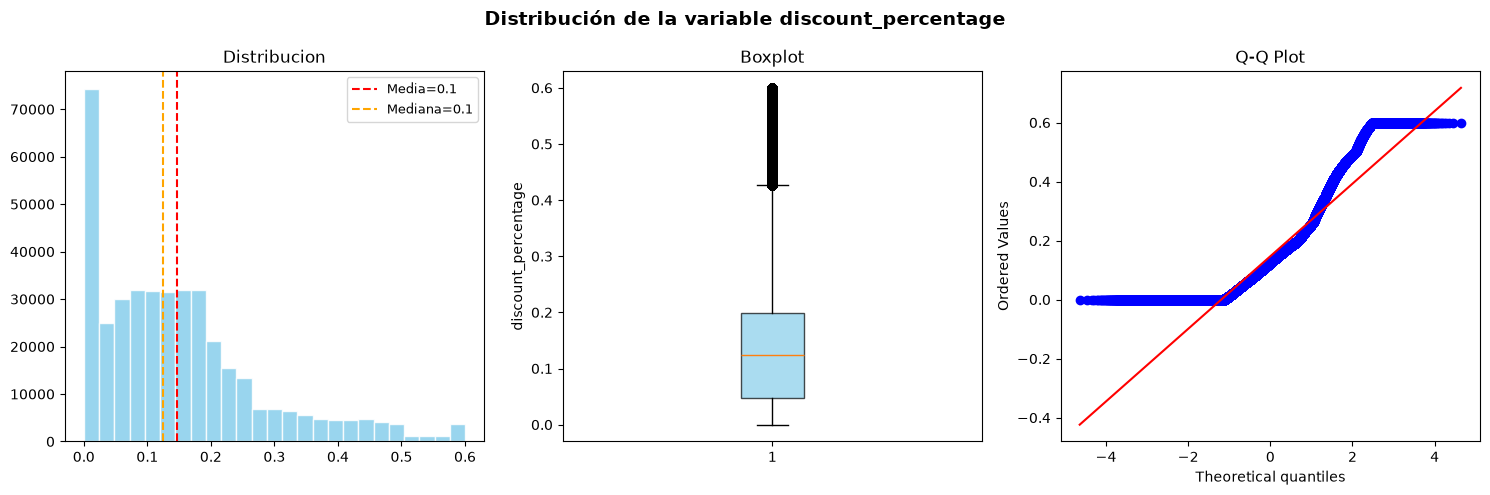

In [43]:
print("\nVisualizacion de distribucion de la variable descuento amount")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribución de la variable discount_percentage", fontsize=14, fontweight='bold')

#Hist
axes[0].hist(df_limpio['discount_percentage'], bins=25, color='skyblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_limpio['discount_percentage'].mean(), color='red', linestyle="--",  label= f"Media={df_limpio['discount_percentage'].mean() :.1f}")
axes[0].axvline(df_limpio['discount_percentage'].median(), color='orange', linestyle="--", label= f"Mediana={df_limpio['discount_percentage'].median() :.1f}")
axes[0].set_title('Distribucion')
axes[0].legend(fontsize=9)


#Box
axes[1].boxplot(df_limpio['discount_percentage'], vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue', alpha=0.70))
axes[1].set_title('Boxplot')
axes[1].set_ylabel('discount_percentage')

#QQ
stats.probplot(df_limpio['discount_percentage'], plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt. show()



**Hist.** En el histograma podemos observar que la media es superior a la mediana lo que nos confirma una asimetria positiva sesgada a la derecha. Con una agrupacion de los datos en 0 bastante fuerte con 74,000 registros y el restro de valores entre 0.05 y 0.25 con una frecuencia que va disminuyendo gradualmente.


**Box.** En el boxplot el 50% de los datos se ubican entre el 0.05 y el 0.20 y a partir del 0.43 son valores atipicos.

**QQ.** El Q-Q plot muestra una desviación clara respecto a la línea de normalidad: se observan tramos planos en ambos extremos (acumulación de valores en 0 y en el tope de 0.6) y una forma de "S" en la zona central. Esto indica que la variable no sigue una distribución normal.


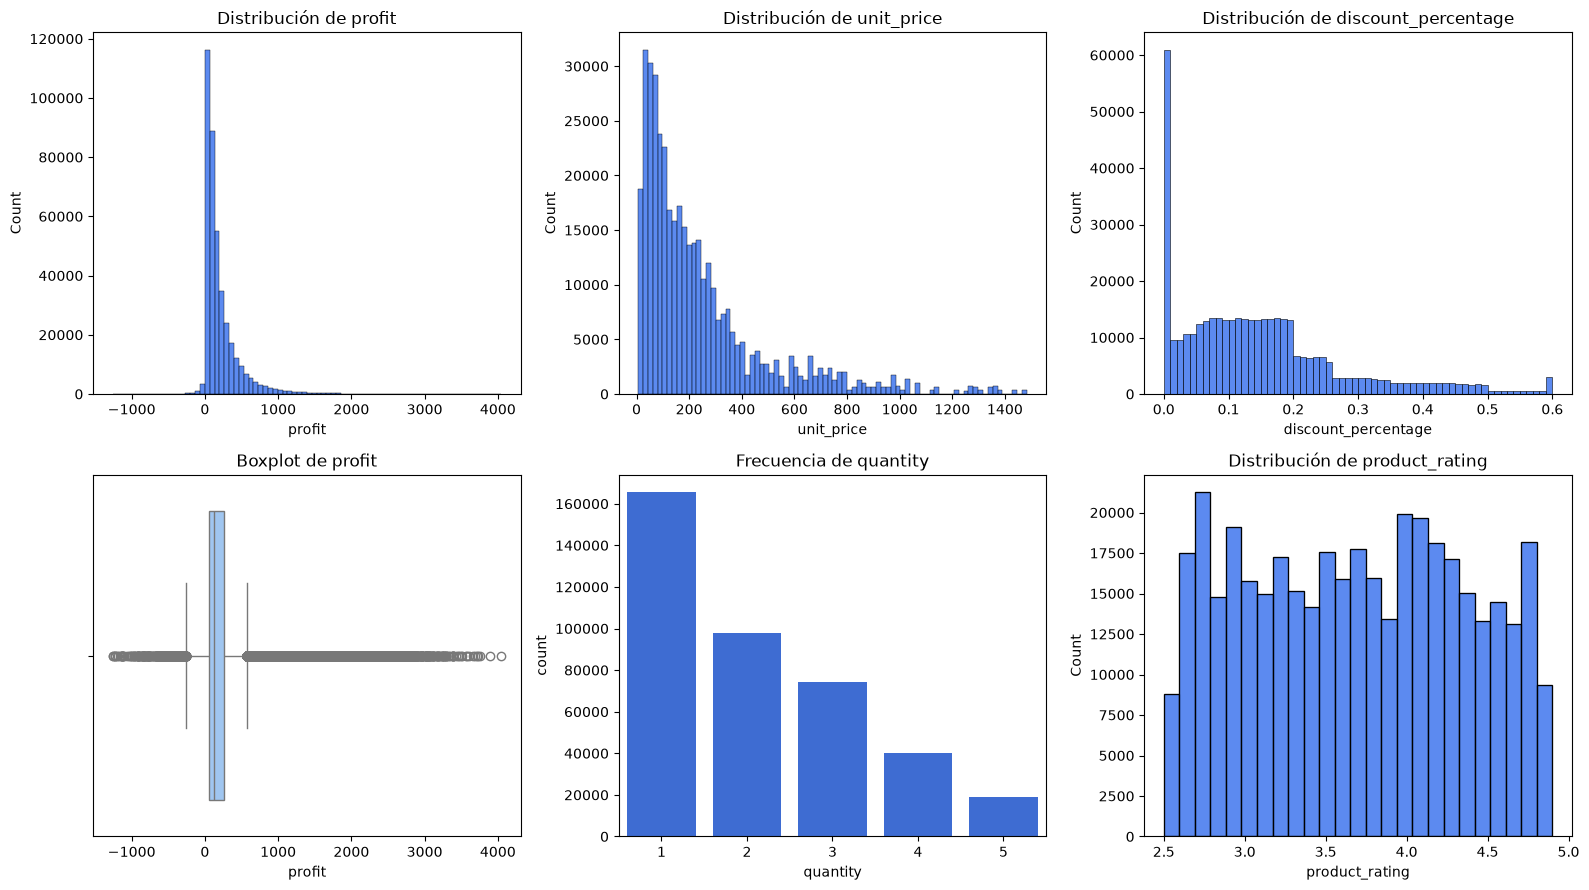

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.histplot(df_limpio["profit"], bins=80, ax=axes[0, 0], color="#2563eb"); axes[0, 0].set_title("Distribución de profit")
sns.histplot(df_limpio["unit_price"], bins=80, ax=axes[0, 1], color="#2563eb"); axes[0, 1].set_title("Distribución de unit_price")
sns.histplot(df_limpio["discount_percentage"], bins=60, ax=axes[0, 2], color="#2563eb"); axes[0, 2].set_title("Distribución de discount_percentage")
sns.boxplot(x=df_limpio["profit"], ax=axes[1, 0], color="#93c5fd"); axes[1, 0].set_title("Boxplot de profit")
sns.countplot(x="quantity", data=df_limpio, ax=axes[1, 1], color="#2563eb"); axes[1, 1].set_title("Frecuencia de quantity")
sns.histplot(df_limpio["product_rating"], bins=25, ax=axes[1, 2], color="#2563eb"); axes[1, 2].set_title("Distribución de product_rating")
plt.tight_layout(); plt.show()

`profit`, `unit_price` y `discount_percentage` Son claramente asimétricas a la derecha. El boxplot de `profit` muestra muchos valores extremos altos (productos de precio alto comprados en mayor cantidad). La mayoría de las líneas compra 1 unidad y la frecuencia cae al subir la cantidad. Estas formas explican por qué se usan pruebas robustas (Welch, Spearman) y por qué una transformación logarítmica podría ayudar en un modelo predictivo.

## 7.3 Variables categóricas

In [54]:
print(col_cat)

['order_id', 'product_id', 'product_name', 'product_category', 'product_subcategory', 'brand', 'supplier']


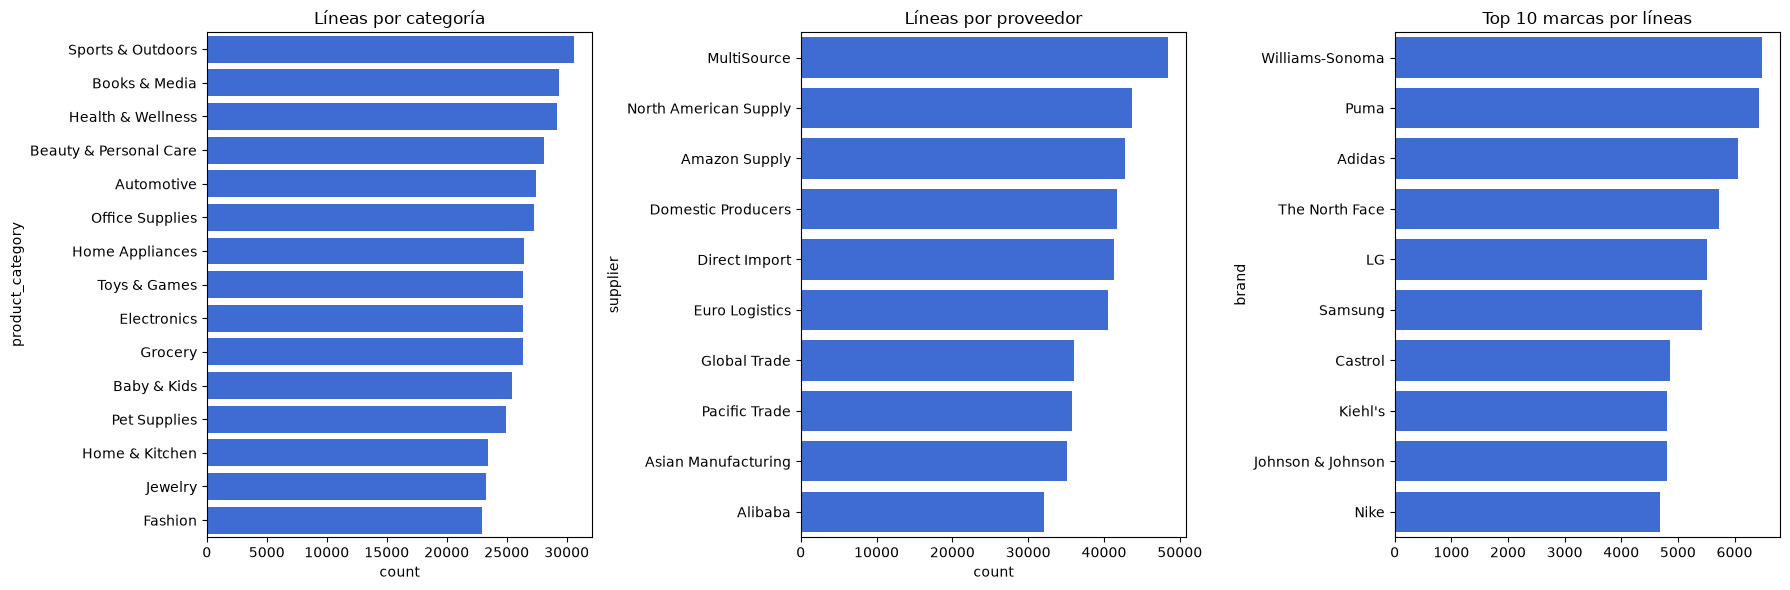

,líneas,porcentaje
product_category,,
Sports & Outdoors,30594,7.70
Books & Media,29363,7.39
Health & Wellness,29188,7.34
Beauty & Personal Care,28107,7.07
Automotive,27480,6.91
Office Supplies,27237,6.85
Home Appliances,26406,6.64
Toys & Games,26390,6.64
Electronics,26387,6.64


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
orden_cat = df_limpio["product_category"].value_counts().index
sns.countplot(y="product_category", data=df_limpio, order=orden_cat, ax=axes[0], color="#2563eb"); axes[0].set_title("Líneas por categoría")
orden_sup = df_limpio["supplier"].value_counts().index
sns.countplot(y="supplier", data=df_limpio, order=orden_sup, ax=axes[1], color="#2563eb"); axes[1].set_title("Líneas por proveedor")
top_brand = df_limpio["brand"].value_counts().head(10)
sns.barplot(x=top_brand.values, y=top_brand.index, ax=axes[2], color="#2563eb"); axes[2].set_title("Top 10 marcas por líneas")
plt.tight_layout(); plt.show()

display(df_limpio["product_category"].value_counts().to_frame("líneas").assign(porcentaje=lambda d: (100 * d["líneas"] / d["líneas"].sum()).round(2)))

El volumen de líneas está bastante equilibrado entre las 15 categorías (entre 5.8% y 7.7% cada una); Sports & Outdoors y Books & Media son las de mayor volumen. Entre los proveedores destaca MultiSource (~12%) y Alibaba es el de menor volumen (~8%). Ninguna marca supera el 2% de las líneas. No hay una categoría, proveedor o marca que domine por volumen.

## 7.4 Relaciones iniciales

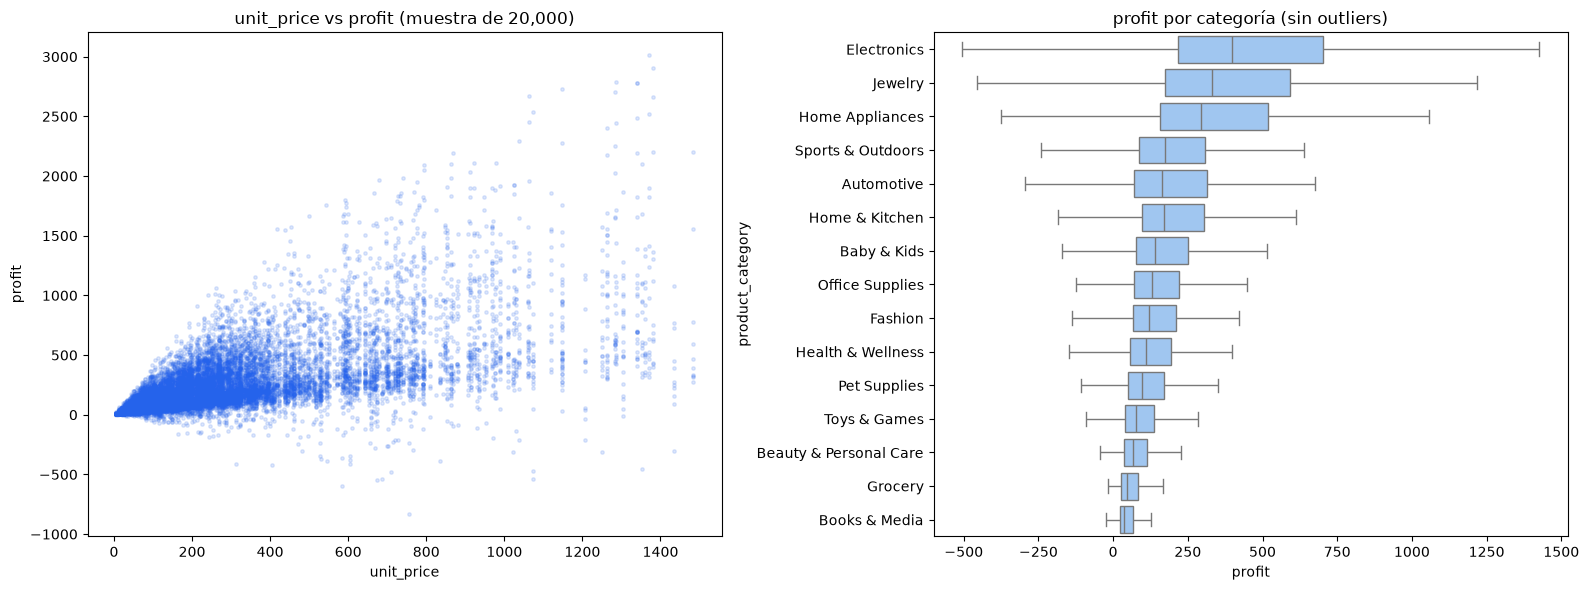

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
muestra = df_limpio.sample(20000, random_state=42)
axes[0].scatter(muestra["unit_price"], muestra["profit"], alpha=0.15, s=6, color="#2563eb")
axes[0].set_xlabel("unit_price"); axes[0].set_ylabel("profit"); axes[0].set_title("unit_price vs profit (muestra de 20,000)")
orden_prof = df_limpio.groupby("product_category")["profit"].mean().sort_values(ascending=False).index
sns.boxplot(y="product_category", x="profit", data=df_limpio, order=orden_prof, ax=axes[1], color="#93c5fd", showfliers=False)
axes[1].set_title("profit por categoría (sin outliers)")
plt.tight_layout(); plt.show()

,lineas,ganancia_media,porcentaje_perdidas
discount_range,,,
0-10%,166516,255.45,0.00
10-20%,132328,194.79,0.00
20-30%,49819,185.02,0.00
30-40%,23230,169.53,0.75
40-60%,25676,47.93,20.45


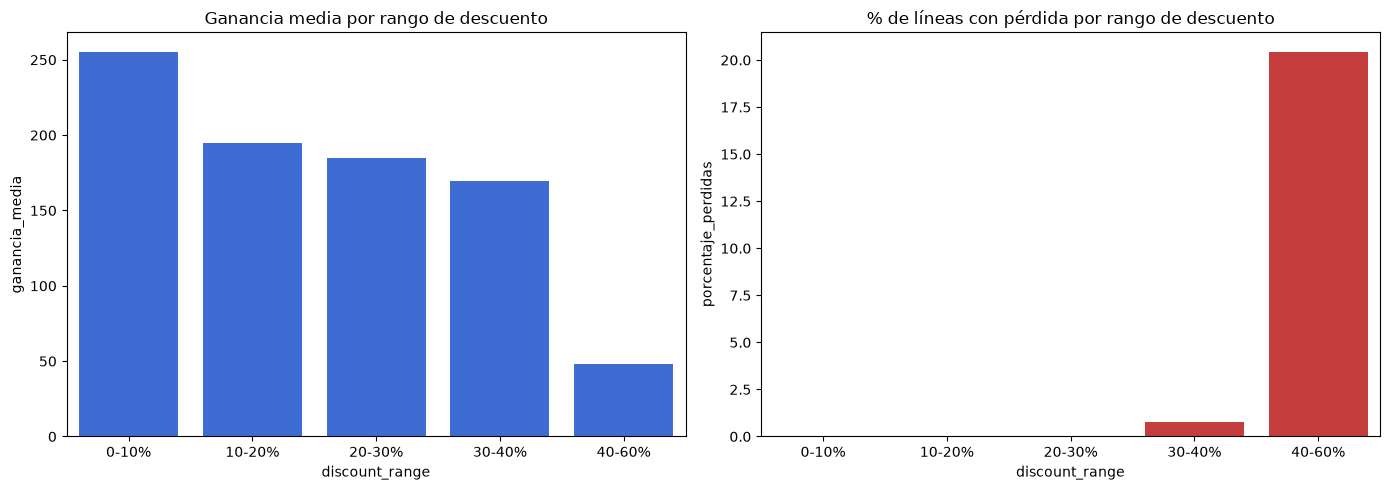

,ganancia_total,ganancia_media,precio_medio
product_category,,,
Electronics,14103982.74,534.50,797.79
Jewelry,10391635.32,446.88,567.23
Home Appliances,10288878.45,389.64,479.34
Sports & Outdoors,7230037.31,236.32,260.96
Automotive,6477194.28,235.71,303.68
Home & Kitchen,5203824.25,221.71,236.72
Baby & Kids,4818148.07,189.38,192.40
Office Supplies,4585377.04,168.35,164.30
Health & Wellness,4263304.41,146.06,158.19


In [51]:
resumen_desc = df_limpio.groupby("discount_range").agg(
    lineas=("profit", "size"),
    ganancia_media=("profit", "mean"),
    porcentaje_perdidas=("is_loss", lambda s: 100 * s.mean())).round(2)
display(resumen_desc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=resumen_desc.index, y=resumen_desc["ganancia_media"], ax=axes[0], color="#2563eb"); axes[0].set_title("Ganancia media por rango de descuento")
sns.barplot(x=resumen_desc.index, y=resumen_desc["porcentaje_perdidas"], ax=axes[1], color="#dc2626"); axes[1].set_title("% de líneas con pérdida por rango de descuento")
plt.tight_layout(); plt.show()

resumen_cat = df_limpio.groupby("product_category").agg(
    ganancia_total=("profit", "sum"), ganancia_media=("profit", "mean"),
    precio_medio=("unit_price", "mean")).sort_values("ganancia_total", ascending=False).round(2)
display(resumen_cat)

- **Precio y ganancia:** a mayor precio unitario, mayor ganancia, pero la dispersión también crece (forma de abanico).  
- **Categorías:** Electronics (\$534 de ganancia media), Jewelry (\$447) y Home Appliances (\$390) lideran; Books & Media (\$50) y Grocery (\$63) cierran. La ganancia sigue de cerca el precio medio de cada categoría.  
- **Descuento:** la ganancia media cae de \$255 (0–10%) a \$48 (40–60%), y el **20.5%** de las líneas con descuento de 40–60% tienen pérdida, frente a prácticamente 0% por debajo de 30%. Esta es la relación más importante para el negocio y motiva la hipótesis 1.

# 8. Planteamiento de hipótesis


## Hipótesis 1

- **Pregunta de análisis:** ¿El porcentaje de descuento aplicado tiene relación con la ganancia (`profit`) de la línea de pedido?  
- **Variables involucradas:** `discount_percentage` (continua), `profit` (continua)  
- **Tipo de variables:** Cuantitativas continuas  
- **H₀:** No existe diferencia en la ganancia promedio entre productos con descuento y sin descuento ($\mu_{\text{con\_desc}} = \mu_{\text{sin\_desc}}$).
- **H₁:** Existe diferencia entre la ganancia media de las líneas con descuento y las sin descuento ($\mu_{con} \neq \mu_{sin}$)
- **Prueba estadística sugerida:** Prueba t de Welch
- **Justificación de la prueba:**  Se comparan las medias de una variable continua entre dos grupos independientes de tamaños y varianzas distintos, por lo que se usa la prueba t de Welch. El tamaño de muestra es grande, lo que respalda su uso aunque `profit` no sea normal.
---
## Hipótesis 2
- **Pregunta de análisis:** ¿La ganancia promedio por línea de pedido difiere entre categorías de producto?  
- **Variables involucradas:** `product_category` (categórica), `profit` (continua)  
- **Tipo de variables:** Una categórica (15 niveles) y una cuantitativa  
- **H₀:** La ganancia promedio es igual en todas las categorías de producto  
- **H₁:** Al menos una categoría tiene una ganancia promedio distinta a las demás  
- **Prueba estadística sugerida:** ANOVA de un factor + Tukey post hoc  
- **Justificación de la prueba:** Se comparan más de dos grupos independientes sobre una variable continua.
---
## Hipótesis 3
- **Pregunta de análisis:** ¿La calificación del producto (`product_rating`) se relaciona con la cantidad vendida (`quantity`) por línea de pedido?  
- **Variables involucradas:** `product_rating` (continua), `quantity` (discreta)  
- **Tipo de variables:** Cuantitativas  
- **H₀:** No existe correlación entre product_rating y quantity ($\rho = 0$)  
- **H₁:** Existe correlación entre product_rating y quantity ($\rho \neq 0$)  
- **Prueba estadística sugerida:** Correlación de Spearman  
- **Justificación de la prueba:** Al ser `quantity` una variable discreta acotada, una correlación no paramétrica es más robusta.
---
## Hipótesis 4
- **Pregunta de análisis:** ¿El costo de envío (`shipping_cost`) promedio difiere según el proveedor (`supplier`) del producto?  
- **Variables involucradas:** `supplier` (categórica), `shipping_cost` (continua)  
- **Tipo de variables:** Categórica (múltiples grupos) y cuantitativa  
- **H₀:** El costo de envío promedio es igual entre todos los proveedores  
- **H₁:** Al menos un proveedor presenta un costo de envío promedio distinto  
- **Prueba estadística sugerida:** ANOVA de un factor + Tukey post hoc  
- **Justificación de la prueba:** Permite comparar una variable continua entre múltiples grupos categóricos.
---
## Hipótesis 5
- **Pregunta de análisis:** ¿La ganancia promedio difiere entre productos con precio unitario "alto" y "bajo" (usando la mediana como corte)?  
- **Variables involucradas:** `unit_price` recodificada en binaria (Alto/Bajo), `profit` (continua)  
- **Tipo de variables:** Categórica binaria y cuantitativa continua  
- **H₀:** La ganancia promedio es igual en ambos grupos de precio  
- **H₁:** La ganancia promedio difiere entre productos de precio alto y bajo  
- **Prueba estadística sugerida:** t-test para muestras independientes (Welch)  
- **Justificación de la prueba:** Se comparan exactamente dos grupos independientes sobre una variable continua.

# 9. Intervalos de confianza
En esta sección calcularemos el intervalo de confianza del 95% para la ganancia promedio (`profit`) por línea de pedido del negocio, lo que nos permitirá estimar el rango real del rendimiento financiero de las transacciones.

- **Parámetro estimado:** la media poblacional de la ganancia (`profit`) por línea de pedido, μ.  
- **Nivel de confianza:** 95%.  
- **Por qué ese nivel:** es el estándar académico y de negocio; equilibra el riesgo de error con la amplitud del intervalo. Con n cercano a 400 mil, el intervalo resulta muy estrecho igualmente.

In [52]:
n = len(df_limpio)
media = df_limpio["profit"].mean()
sd = df_limpio["profit"].std()
sem = stats.sem(df_limpio["profit"])
ic95 = stats.t.interval(0.95, n - 1, loc=media, scale=sem)

print("n =", n)
print("Media muestral de profit = %.2f" % media)
print("Desviación estándar      = %.2f" % sd)
print("Error estándar           = %.4f" % sem)
print("IC 95%% para la media de profit: [%.2f, %.2f]" % ic95)

# Complemento: IC 95% para la proporción de líneas con pérdida
p_hat = df_limpio["is_loss"].mean()
se_p = np.sqrt(p_hat * (1 - p_hat) / n)
print("\nProporción de líneas con pérdida = %.4f" % p_hat)
print("IC 95%% para la proporción: [%.4f, %.4f]" % (p_hat - 1.96 * se_p, p_hat + 1.96 * se_p))

n = 397569
Media muestral de profit = 208.01
Desviación estándar      = 266.48
Error estándar           = 0.4226
IC 95% para la media de profit: [207.18, 208.84]

Proporción de líneas con pérdida = 0.0136
IC 95% para la proporción: [0.0133, 0.0140]


Con un 95% de confianza, estimamos que el verdadero valor de la ganancia promedio por transacción en todo el e-commerce se encuentra entre los límites calculados. Esto nos da un rango estadísticamente seguro sobre la rentabilidad general del negocio.

Es decir, con un 95% de confianza, la ganancia media real por línea de pedido está entre **\$207.18 y \$208.84**. El intervalo mide menos de \$2 de ancho gracias al enorme tamaño de muestra, por lo que el valor promedio está estimado con mucha precisión. Esto **no** significa que cada línea gane cerca de \$208: la desviación estándar es \$266, así que la ganancia individual varía mucho alrededor de esa media. Como complemento, el intervalo para la proporción de líneas con pérdida (≈1.36%) es muy angosto: las pérdidas son poco frecuentes, pero constantes.

# 10. Pruebas estadísticas


## Hipótesis 1
**HIPOTESIS TARGET**
- **Pregunta de análisis:** ¿El porcentaje de descuento aplicado tiene relación con la ganancia (`profit`) de la línea de pedido?  
- **Variables involucradas:** `discount_percentage` (continua), `profit` (continua)  
- **Tipo de variables:** Cuantitativas continuas  
- **H₀:** No existe diferencia en la ganancia promedio entre productos con descuento y sin descuento ($\mu_{\text{con\_desc}} = \mu_{\text{sin\_desc}}$).
- **H₁:** Existe diferencia entre la ganancia media de las líneas con descuento y las sin descuento ($\mu_{con} \neq \mu_{sin}$)
- **Prueba estadística sugerida:** Prueba t de Welch
- **Justificación de la prueba:**  Se comparan las medias de una variable continua entre dos grupos independientes de tamaños y varianzas distintos, por lo que se usa la prueba t de Welch. El tamaño de muestra es grande, lo que respalda su uso aunque `profit` no sea normal.

In [90]:
print("\nPruebas de hipotesis 1")
print("-" * 50)

print("Comparacion de ganancias entre productos con y sin descuento")

def prueba_hipotesis(nombre,stat, p, alpha=0.05):
    conclusion="SE RECHAZA H0" if p < alpha else "NO SE RECHAZA H0"
    print(f"\nPrueba de Hipotesis: {nombre}")
    print(f"Estadistico de prueba: {stat:.4f}")
    print(f"Valor p: {p:.4f}")
    print(f"Conclusión: {conclusion} (alpha={alpha})")
    
g1_si=df_limpio[df_limpio['discount_percentage']>0]['profit']
g2_no=df_limpio[df_limpio['discount_percentage']==0]['profit']
t, p_t = stats.ttest_ind(g1_si, g2_no, equal_var=False) 

prueba_hipotesis("Comparacion de ganancias entre productos con y sin descuento", t, p_t)
print(f"Media de ganancias con descuento: {g1_si.mean():.2f}")
print(f"Media de ganancias sin descuento: {g2_no.mean():.2f}")
print(f"Existe diferencia {g1_si.mean() - g2_no.mean():.2f}")


Pruebas de hipotesis 1
--------------------------------------------------
Comparacion de ganancias entre productos con y sin descuento

Prueba de Hipotesis: Comparacion de ganancias entre productos con y sin descuento
Estadistico de prueba: -48.1146
Valor p: 0.0000
Conclusión: SE RECHAZA H0 (alpha=0.05)
Media de ganancias con descuento: 198.37
Media de ganancias sin descuento: 272.81
Existe diferencia -74.44


Interpretacion:

Se compararon las ganancias medias por línea de pedido entre productos con descuento y sin descuento. La prueba t welch mostró una diferencia estadísticamente significativa (t = -48.11; p < 0.001), por lo que se rechaza H₀. Las líneas con descuento tuvieron una ganancia media de 198.37, frente a 272.81 en las líneas sin descuento, es decir, 74.44 menos en promedio. Esto indica que aplicar descuento se asocia con una menor ganancia por línea de pedido

---

## Hipótesis 2
- **Pregunta de análisis:** ¿La ganancia promedio por línea de pedido difiere entre categorías de producto?  
- **Variables involucradas:** `product_category` (categórica), `profit` (continua)  
- **Tipo de variables:** Una categórica (15 niveles) y una cuantitativa  
- **H₀:** La ganancia promedio es igual en todas las categorías de producto  
- **H₁:** Al menos una categoría tiene una ganancia promedio distinta a las demás  
- **Prueba estadística sugerida:** ANOVA de un factor + Tukey post hoc  
- **Justificación de la prueba:** Se comparan más de dos grupos independientes sobre una variable continua.


In [96]:


print("\nPruebas de hipotesis 2")
print("-" * 50)

print("Categoria que afecta a las ganancias")

def prueba_hipotesis(nombre,stat, p, alpha=0.05):
    conclusion="SE RECHAZA H0" if p < alpha else "NO SE RECHAZA H0"
    print(f"\nPrueba de Hipotesis: {nombre}")
    print(f"Estadistico de prueba: {stat:.4f}")
    print(f"Valor p: {p:.4f}")
    print(f"Conclusión: {conclusion} (alpha={alpha})")
    

grupos_cat = [df_limpio.loc[df_limpio['product_category'] == c,'profit'].values
              for c in df_limpio['product_category'].unique()]

f, p_f = stats.f_oneway(*grupos_cat)

prueba_hipotesis("Categoria afecta las ganancias", f, p_f)

if p_f < 0.05:
    if p_f < 0.05:
        tukey = pairwise_tukeyhsd(
        endog=df_limpio['profit'],
        groups=df_limpio['product_category'],
        alpha=0.05,
    )
    print("Post hoc de Tukey (pares con diferencia significativa)")
    print(tukey.summary())
else:
    print("\n No se encontraron diferencias significativas")


Pruebas de hipotesis 2
--------------------------------------------------
Categoria que afecta a las ganancias

Prueba de Hipotesis: Categoria afecta las ganancias
Estadistico de prueba: 10073.9671
Valor p: 0.0000
Conclusión: SE RECHAZA H0 (alpha=0.05)
Post hoc de Tukey (pares con diferencia significativa)
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
        group1                 group2          meandiff p-adj    lower     upper   reject
-----------------------------------------------------------------------------------------
            Automotive            Baby & Kids   -46.328    0.0  -53.0831   -39.573   True
            Automotive Beauty & Personal Care -147.5615    0.0 -154.1482 -140.9749   True
            Automotive          Books & Media -185.4556    0.0 -191.9722 -178.9389   True
            Automotive            Electronics  298.7992    0.0  292.1073  305.4912   True
            Automotive                Fashion  -75.5577    0.

Interpretacion:

El ANOVA de un factor indicó diferencias significativas en la ganancia media entre categorías de producto (F = 10,073.97; p < 0.001), por lo que se rechaza H₀. La prueba post hoc de Tukey mostró que 104 de las 105 comparaciones por pares fueron significativas; la única excepción fue Automotive vs. Sports & Outdoors (diferencia = 0.62; p = 1.0). Electronics presentó la mayor ganancia media, seguida de Jewelry (87.63 menos que Electronics) y Home Appliances (144.86 menos), mientras que Books & Media, Grocery y Beauty & Personal Care presentaron las más bajas, con diferencias de 484.25, 471.96 y 446.36 respecto a Electronics.

---


## Hipótesis 3
- **Pregunta de análisis:** ¿La calificación del producto (`product_rating`) se relaciona con la cantidad vendida (`quantity`) por línea de pedido?  
- **Variables involucradas:** `product_rating` (continua), `quantity` (discreta)  
- **Tipo de variables:** Cuantitativas  
- **H₀:** No existe correlación entre product_rating y quantity ($\rho = 0$)  
- **H₁:** Existe correlación entre product_rating y quantity ($\rho \neq 0$)  
- **Prueba estadística sugerida:** Correlación de Spearman  
- **Justificación de la prueba:** Al ser `quantity` una variable discreta acotada, una correlación no paramétrica es más robusta.

In [93]:
print("\nPruebas de hipotesis 3")
print("-" * 50)

print("Prueba: calificación del producto y cantidad vendida")

rho, p_s = stats.spearmanr(df_limpio['product_rating'], df_limpio['quantity'])

prueba_hipotesis("Correlación de Spearman (rating vs. cantidad)", rho, p_s)
print(f"Coeficiente rho: {rho:.4f}")
print(f"n = {len(df_limpio)}")


Pruebas de hipotesis 3
--------------------------------------------------
Prueba: calificación del producto y cantidad vendida

Prueba de Hipotesis: Correlación de Spearman (rating vs. cantidad)
Estadistico de prueba: -0.0002
Valor p: 0.8905
Conclusión: NO SE RECHAZA H0 (alpha=0.05)
Coeficiente rho: -0.0002
n = 397569


Interpretacion:

La correlación de Spearman entre product_rating y quantity fue prácticamente nula (ρ = -0.0002; p = 0.8905; n = 397,569), por lo que no se rechaza H₀. No se encontró evidencia de relación entre la calificación del producto y la cantidad vendida por línea de pedido. 

---

## Hipótesis 4
- **Pregunta de análisis:** ¿El costo de envío (`shipping_cost`) promedio difiere según el proveedor (`supplier`) del producto?  
- **Variables involucradas:** `supplier` (categórica), `shipping_cost` (continua)  
- **Tipo de variables:** Categórica (múltiples grupos) y cuantitativa  
- **H₀:** El costo de envío promedio es igual entre todos los proveedores  
- **H₁:** Al menos un proveedor presenta un costo de envío promedio distinto  
- **Prueba estadística sugerida:** ANOVA de un factor + Tukey post hoc  
- **Justificación de la prueba:** Permite comparar una variable continua entre múltiples grupos categóricos.

In [94]:
print("\nPruebas de hipotesis 4")
print("-" * 50)
print("Costo de envio segun el proveedor")

grupos_sup = [df_limpio.loc[df_limpio['supplier'] == s, 'shipping_cost'].values for s in df_limpio['supplier'].unique()]
f, p_f = stats.f_oneway(*grupos_sup)
prueba_hipotesis("Anova (Proveedor)", f, p_f)

if p_f < 0.05:
    tukey = pairwise_tukeyhsd(df_limpio['shipping_cost'], df_limpio['supplier'], alpha=0.05)
    tabla = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    print("\nPost hoc de Tukey (pares con diferencia significativa)")
    print(tabla[tabla['reject']])
else:
    print("\nNo aplicamos Tukey: Anova no encontro diferencias")


Pruebas de hipotesis 4
--------------------------------------------------
Costo de envio segun el proveedor

Prueba de Hipotesis: Anova (Proveedor)
Estadistico de prueba: 0.6845
Valor p: 0.7238
Conclusión: NO SE RECHAZA H0 (alpha=0.05)

No aplicamos Tukey: Anova no encontro diferencias


Interpretacion:

El ANOVA de un factor no encontró diferencias significativas en el costo de envío promedio entre proveedores (F = 0.6845; p = 0.7238), por lo que no se rechaza H₀. No existe evidencia de que el proveedor del producto influya en el costo de envío. 

---

## Hipótesis 5
- **Pregunta de análisis:** ¿La ganancia promedio difiere entre productos con precio unitario "alto" y "bajo" (usando la mediana como corte)?  
- **Variables involucradas:** `unit_price` recodificada en binaria (Alto/Bajo), `profit` (continua)  
- **Tipo de variables:** Categórica binaria y cuantitativa continua  
- **H₀:** La ganancia promedio es igual en ambos grupos de precio  
- **H₁:** La ganancia promedio difiere entre productos de precio alto y bajo  
- **Prueba estadística sugerida:** t-test para muestras independientes (Welch)  
- **Justificación de la prueba:** Se comparan exactamente dos grupos independientes sobre una variable continua.

In [95]:
print("\nPruebas de hipotesis 5")
print("-" * 50)
print("Comparacion de ganancias entre productos de precio alto y bajo")

mediana_precio = df_limpio['unit_price'].median()
print(f"Mediana de unit_price (punto de corte): {mediana_precio:.2f}")

g1_alto = df_limpio.loc[df_limpio['unit_price'] > mediana_precio, 'profit']
g2_bajo = df_limpio.loc[df_limpio['unit_price'] <= mediana_precio, 'profit']
t, p_t = stats.ttest_ind(g1_alto, g2_bajo, equal_var=False,)

prueba_hipotesis("t de Welch: ganancias precio alto vs. precio bajo", t, p_t)
print(f"Media de ganancias precio alto: {g1_alto.mean():.2f} (n={g1_alto.count()})")
print(f"Media de ganancias precio bajo: {g2_bajo.mean():.2f} (n={g2_bajo.count()})")
print(f"Diferencia: {g1_alto.mean() - g2_bajo.mean():.2f}")


Pruebas de hipotesis 5
--------------------------------------------------
Comparacion de ganancias entre productos de precio alto y bajo
Mediana de unit_price (punto de corte): 164.97

Prueba de Hipotesis: t de Welch: ganancias precio alto vs. precio bajo
Estadistico de prueba: 349.3617
Valor p: 0.0000
Conclusión: SE RECHAZA H0 (alpha=0.05)
Media de ganancias precio alto: 337.18 (n=198761)
Media de ganancias precio bajo: 78.86 (n=198808)
Diferencia: 258.32


Interpretacion:

La prueba t de Welch mostró una diferencia significativa en la ganancia media entre productos de precio unitario alto y bajo, usando la mediana (164.97) como punto de corte (t = 349.36; p < 0.001), por lo que se rechaza H₀. Los productos de precio alto presentaron una ganancia media de 337.18, frente a 78.86 en los de precio bajo, una diferencia de 258.32. Los grupos tuvieron tamaños prácticamente iguales (n = 198,761 y n = 198,808). 


# 11. Correlación

Matriz de correlación de Pearson con las variables numéricas relevantes

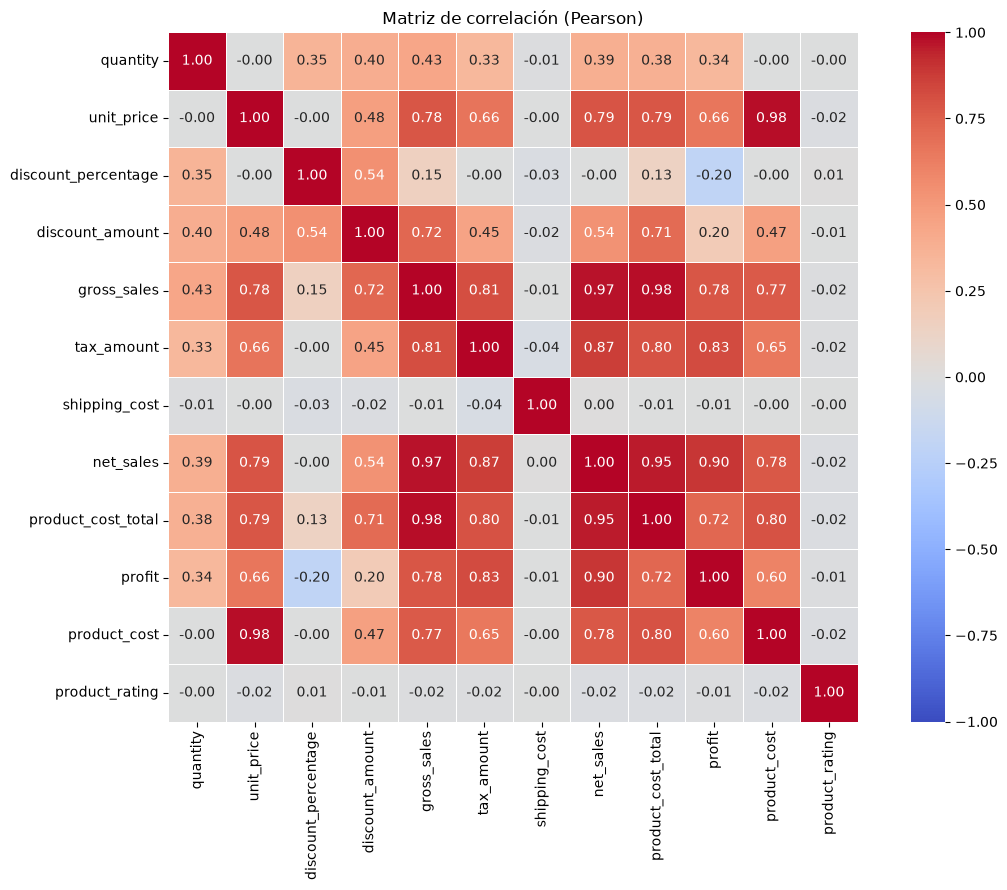

Correlación de cada variable con profit:


,r con profit
net_sales,0.896
tax_amount,0.827
gross_sales,0.784
product_cost_total,0.722
unit_price,0.661
product_cost,0.602
quantity,0.335
discount_amount,0.199
shipping_cost,-0.006
product_rating,-0.012


,var1,var2,r
52,gross_sales,product_cost_total,0.982
20,unit_price,product_cost,0.980
51,gross_sales,net_sales,0.969
85,net_sales,product_cost_total,0.954
62,tax_amount,net_sales,0.872
49,gross_sales,tax_amount,0.815
97,product_cost_total,product_cost,0.803
63,tax_amount,product_cost_total,0.802


In [55]:
corr = df_limpio[col_num].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout(); plt.show()

print("Correlación de cada variable con profit:")
display(corr["profit"].drop("profit").sort_values(ascending=False).round(3).to_frame("r con profit"))

# Pares de predictores muy correlacionados entre sí (|r| > 0.8), excluyendo profit
pares = (corr.drop(index="profit", columns="profit").where(np.triu(np.ones((len(corr) - 1, len(corr) - 1)), k=1).astype(bool))
         .stack().reset_index())
pares.columns = ["var1", "var2", "r"]
display(pares[pares["r"].abs() > 0.8].sort_values("r", ascending=False).round(3))

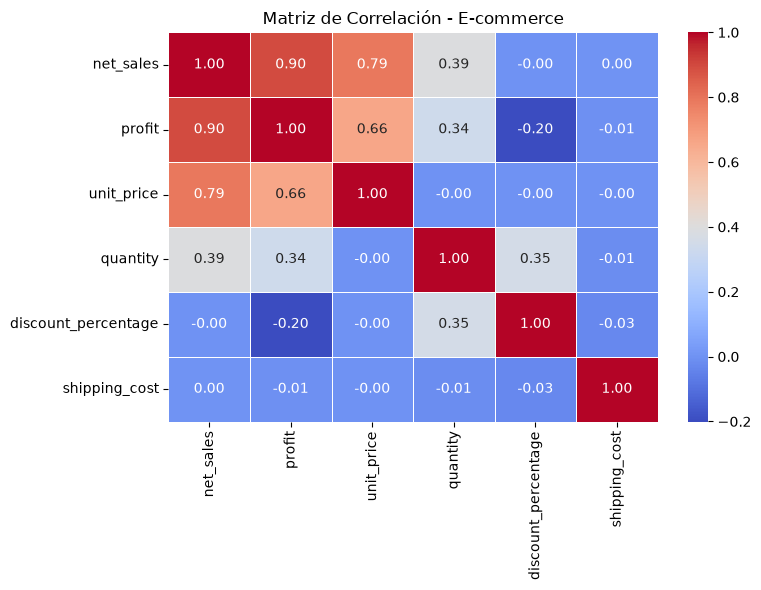

In [79]:
# 11. Matriz de correlación para las variables numéricas del dataset de e-commerce
vars_corr = ['net_sales', 'profit', 'unit_price', 'quantity', 'discount_percentage', 'shipping_cost']

# Asegurar que todas las columnas seleccionadas sean numéricas antes de correlacionar
df_corr_num = df_limpio[vars_corr].apply(pd.to_numeric, errors='coerce')
matriz_corr = df_corr_num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - E-commerce')
plt.tight_layout()
plt.show()

**¿Qué variables tienen mayor correlación con `profit`?**  
`net_sales` (≈ 0.90), `tax_amount` (≈ 0.83), `gross_sales` (≈ 0.78) y `product_cost_total` (≈ 0.72), seguidas de `unit_price` (≈ 0.66) y `product_cost` (≈ 0.60). Las de menor relación son `quantity` (≈ 0.34), `discount_percentage` (≈ −0.20) y prácticamente nulas `shipping_cost` y `product_rating`.

**¿Positiva o negativa?**  
Casi todas positivas; la única negativa relevante es `discount_percentage` (a mayor descuento, menor ganancia).

**¿Fuerte, moderada o débil?**  
Fuertes (> 0.7): `net_sales`, `tax_amount`, `gross_sales`, `product_cost_total`. Moderada: `unit_price`. Débiles: `quantity` y `discount_percentage`. Nulas: `shipping_cost` y `product_rating`.

**¿Predictores muy correlacionados entre sí?**  
Sí, hay **multicolinealidad fuerte** entre `gross_sales`, `net_sales`, `tax_amount` y `product_cost_total` (correlaciones de 0.8 a 0.98), porque todas derivan de precio × cantidad. También `unit_price` y `product_cost` están casi duplicadas (r ≈ 0.98): el costo unitario es una fracción del precio. Además, `net_sales`, `tax_amount` y `gross_sales` casi "contienen" a `profit` por construcción (`profit = net_sales − envío − costo_total`, con impuesto incluido), por lo que su alta correlación es en gran parte **mecánica**, no informativa.


### Conclusion
**Correlación no implica causalidad.** Que `tax_amount` correlacione con `profit` no significa que el impuesto cause ganancia; ambos crecen con el monto de la venta.

# 12. Regresión lineal simple

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
X = df_limpio[["unit_price"]].values
y = df_limpio["profit"].values

modelo = LinearRegression().fit(X, y)
y_pred = modelo.predict(X)

b0, b1 = modelo.intercept_, modelo.coef_[0]
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("Ecuación: profit = %.4f + %.4f * unit_price" % (b0, b1))
print("R²   = %.4f" % r2)
print("MSE  = %.2f" % mse)
print("RMSE = %.2f" % rmse)

# Significancia de la pendiente (statsmodels)
ols = sm.OLS(y, sm.add_constant(X)).fit()
print("\nPendiente: %.4f, p-value = %.3g, IC 95%% = [%.4f, %.4f]" % (ols.params[1], ols.pvalues[1], *ols.conf_int()[1]))

# Validación: entrenamiento 80% / prueba 20%
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
m2 = LinearRegression().fit(X_tr, y_tr)
p_te = m2.predict(X_te)
print("\nConjunto de prueba -> R² = %.4f, RMSE = %.2f" % (r2_score(y_te, p_te), np.sqrt(mean_squared_error(y_te, p_te))))

df_limpio["profit_pred"] = y_pred
df_limpio["residuo"] = y - y_pred

Ecuación: profit = 35.9486 + 0.7017 * unit_price
R²   = 0.4370
MSE  = 39976.83
RMSE = 199.94

Pendiente: 0.7017, p-value = 0, IC 95% = [0.6993, 0.7042]

Conjunto de prueba -> R² = 0.4423, RMSE = 197.86


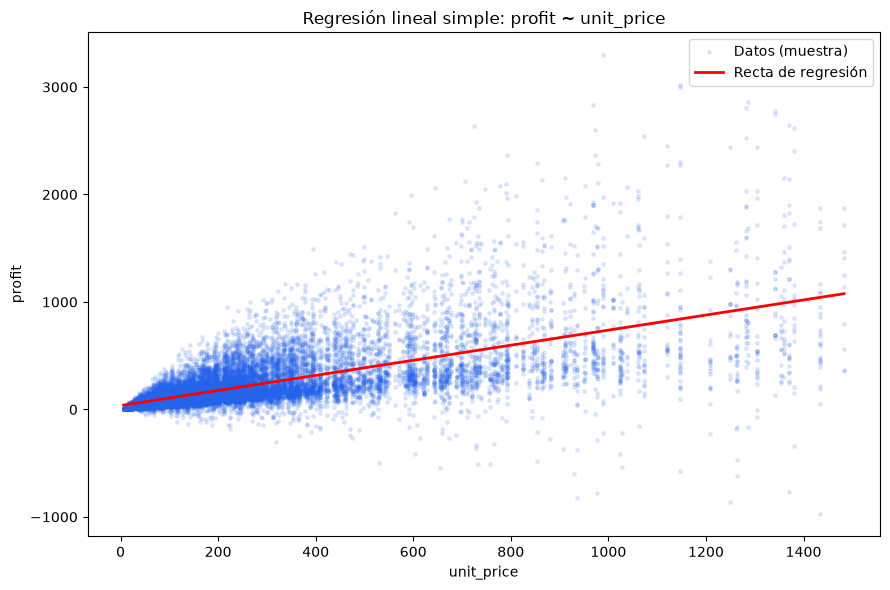

In [72]:
plt.figure(figsize=(9, 6))
muestra = df_limpio.sample(20000, random_state=1)
plt.scatter(muestra["unit_price"], muestra["profit"], alpha=0.12, s=6, color="#2563eb", label="Datos (muestra)")
xs = np.linspace(df_limpio["unit_price"].min(), df_limpio["unit_price"].max(), 100)
plt.plot(xs, b0 + b1 * xs, color="red", linewidth=2, label="Recta de regresión")
plt.xlabel("unit_price"); plt.ylabel("profit"); plt.title("Regresión lineal simple: profit ~ unit_price"); plt.legend()
plt.tight_layout(); plt.show()

| Elemento | Respuesta |
|---|---|
| Variable dependiente Y | `profit` |
| Variable independiente X | `unit_price` |
| Ecuación del modelo | `profit = 35.9486 + 0.7017 × unit_price` |
| Interpretación de la pendiente | `Por cada aumento de 1 unidad monetaria en unit_price, el profit esperado aumenta aproximadamente 0.7017 unidades monetarias, en promedio.` |
| R² | 0.4370 |
| MSE | 39,976.83 |
| RMSE | 199.94 |

El precio unitario explica alrededor del **43.7%** de la variabilidad de la ganancia por línea: una relación moderada y muy significativa (la pendiente tiene p ≈ 0), pero insuficiente por sí sola. El RMSE de ≈ \$200 indica que las predicciones se desvían en promedio unos \$200 de la ganancia real, una magnitud comparable a la media de la ganancia (\$208). El desempeño en el conjunto de prueba es equivalente al del ajuste completo, así que el modelo no sobreajusta (es un modelo de solo 2 parámetros y ~400 mil datos). Sus limitaciones: ignora la cantidad, el descuento y la categoría (que la Sección 10 mostró importantes), asume linealidad y varianza constante (que, como se verá, no se cumple) y no distingue entre líneas con descuento alto y bajo.

> **Resumen**: El modelo confirma que existe una relación positiva entre el precio unitario y la ganancia, pero los residuales y el R² muestran que existen otros factores importantes que también explican la variabilidad del profit.

# 13. Análisis de residuos

In [75]:
from statsmodels.stats.diagnostic import het_breuschpagan
res = df_limpio["residuo"]
print("Media de los residuos: %.6f" % res.mean())
print("Desviación estándar  : %.2f" % res.std())
print("Asimetría: %.2f | Curtosis (exceso): %.2f" % (res.skew(), res.kurt()))

bp = het_breuschpagan(res, sm.add_constant(df_limpio[["unit_price"]]))
print("Breusch-Pagan (heterocedasticidad): LM = %.1f, p-value = %.3g" % (bp[0], bp[1]))

# Desviación de los residuos por grupos de precio predicho
df_limpio["tramo_precio"] = pd.qcut(df_limpio["unit_price"], 5, labels=["Q1 (bajo)", "Q2", "Q3", "Q4", "Q5 (alto)"])
display(df_limpio.groupby("tramo_precio", observed=True)["residuo"].agg(["mean", "std"]).round(2))

Media de los residuos: 0.000000
Desviación estándar  : 199.94
Asimetría: 2.09 | Curtosis (exceso): 19.55
Breusch-Pagan (heterocedasticidad): LM = 61118.8, p-value = 0


,mean,std
tramo_precio,,
Q1 (bajo),-22.78,26.67
Q2,-8.52,59.10
Q3,7.58,107.78
Q4,22.27,173.98
Q5 (alto),1.45,391.25


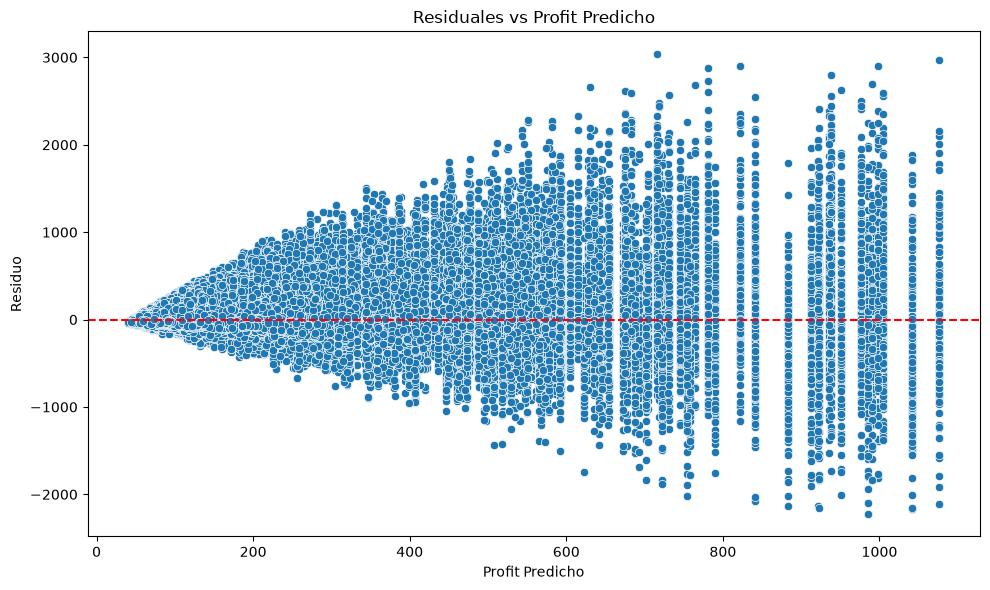

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="profit_pred", y="residuo", data=df_limpio)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Profit Predicho")
plt.ylabel("Residuo")
plt.title("Residuales vs Profit Predicho")
plt.tight_layout()
plt.show()

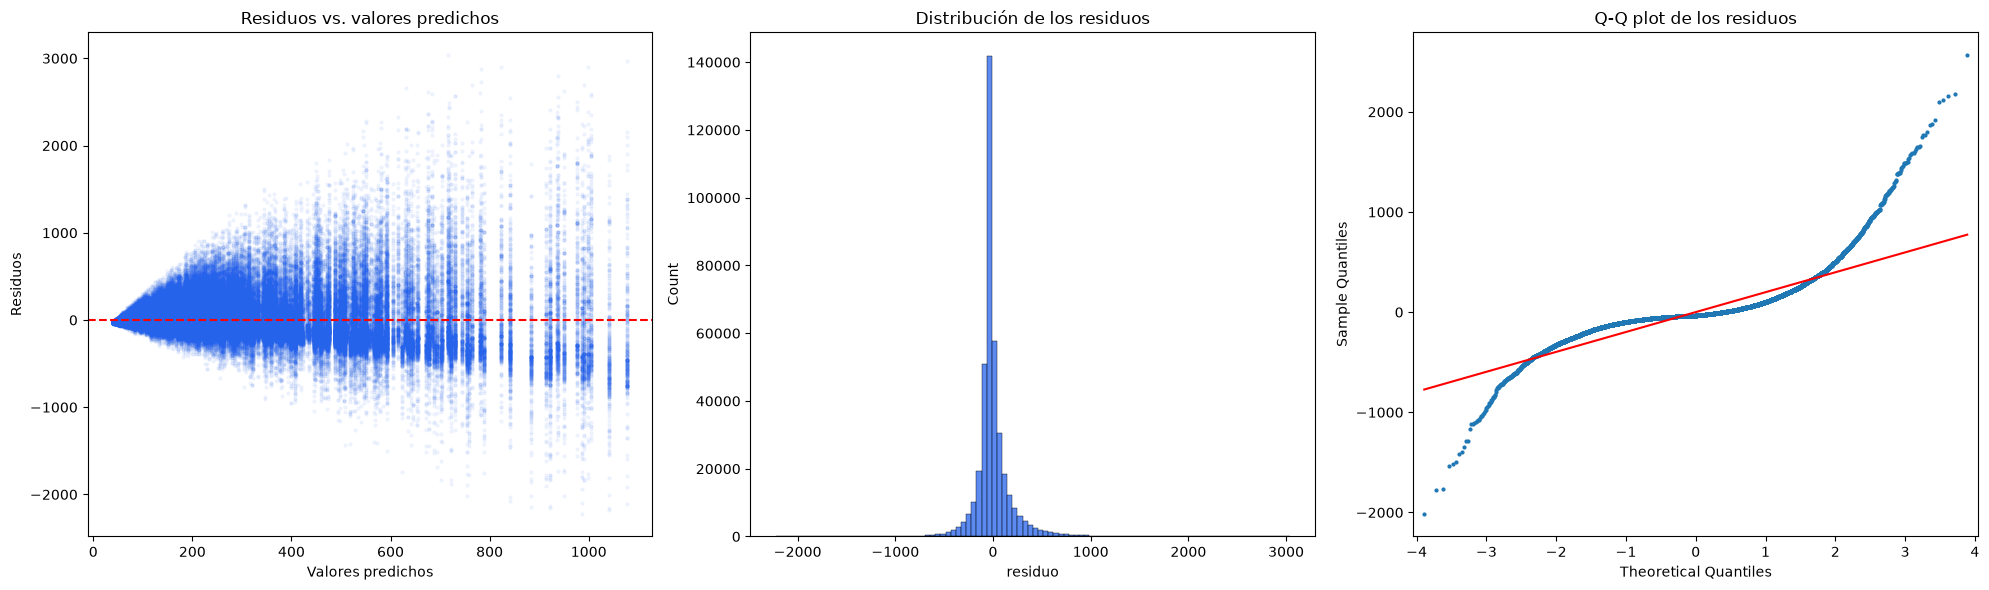

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(df_limpio["profit_pred"], df_limpio["residuo"], alpha=0.05, s=5, color="#2563eb")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valores predichos"); axes[0].set_ylabel("Residuos"); axes[0].set_title("Residuos vs. valores predichos")

sns.histplot(res, bins=100, ax=axes[1], color="#2563eb"); axes[1].set_title("Distribución de los residuos")

sm.qqplot(res.sample(20000, random_state=1), line="s", ax=axes[2], markersize=2)
axes[2].set_title("Q-Q plot de los residuos")
plt.tight_layout(); plt.show()

**¿Los residuos tienen media cercana a cero?**  
Sí, la media es 0 (propiedad de mínimos cuadrados con intercepto). Eso no garantiza que el modelo sea adecuado.

**¿Hay patrones visibles?**  
Sí. El gráfico de residuos vs. predichos tiene forma de **embudo**: la dispersión crece con el valor predicho (heterocedasticidad), confirmada por Breusch-Pagan (p ≈ 0) y por la desviación estándar de los residuos por quintil de precio, que pasa de ≈ \$27 (quintil más barato) a ≈ \$391 (más caro). También aparecen bandas verticales, porque hay solo 1,175 precios distintos.

**¿Los errores están distribuidos razonablemente?**  
Solo a medias. El histograma está centrado en cero, pero tiene **asimetría positiva** y colas pesadas (el Q-Q plot se aleja de la línea en ambos extremos), de modo que no son normales. Con este tamaño de muestra la estimación de la pendiente sigue siendo confiable, pero los intervalos y p-values basados en varianza constante no deben tomarse literalmente.

**¿El modelo deja información sin explicar?**  
Sí: queda más del 56% de la variabilidad sin explicar. A igual precio unitario, la ganancia depende de la cantidad, del descuento y de la categoría. Un modelo múltiple, o transformar `profit` y `unit_price` con logaritmo (o modelar el margen en vez de la ganancia absoluta), mejoraría el ajuste.

# 14. Interpretación general de resultados

**Hipótesis rechazadas (evidencia a favor de H₁):**  
- **H1:** descuento y ganancia se correlacionan negativamente (r ≈ −0.20).  
- **H2:** la ganancia media difiere entre categorías (ANOVA y Tukey).  
- **H5:** los productos de precio alto generan mucha más ganancia que los de precio bajo (t de Welch).

**Hipótesis no rechazadas:**  
- **H3:** no hay relación entre calificación y cantidad comprada (ρ ≈ 0, p ≈ 0.89).  
- **H4:** el costo de envío no difiere entre proveedores (p ≈ 0.72).  

**Variables más relevantes:** `unit_price`, `quantity`, `product_category` y `discount_percentage` para la ganancia. Las variables `product_rating`, `shipping_cost` y `supplier` casi no aportan.

**Relaciones más fuertes:** `profit` con `net_sales` (≈ 0.90, en buena parte mecánica), con `gross_sales` (≈ 0.78) y con `unit_price` (≈ 0.66); esta última es la más útil porque es previa a la venta.

**Resultados estadísticamente significativos:** H1, H2, H5 y la pendiente de la regresión. Con casi 400 mil observaciones casi cualquier diferencia sale significativa, por eso conviene juzgar también el tamaño del efecto.

**Resultados importantes en términos prácticos:**  
1. La diferencia entre categorías (más de \$480 por línea entre Electronics y Books & Media) y entre precio alto y bajo (~4×).  
2. Aunque la correlación global del descuento es débil, los descuentos del **40–60%** hacen caer la ganancia media a unos \$48 y generan pérdidas en 1 de cada 5 líneas.  
3. Como el descuento se reparte igual entre categorías (H6), los porcentajes altos pegan más en las categorías de bajo margen.  
4. Los resultados no significativos también informan: la calificación no mueve el volumen y el proveedor no cambia el envío.
---

Síntesis de los hallazgos obtenidos a lo largo del análisis exploratorio, las pruebas estadísticas y los modelos predictivos.

In [77]:
# Resumen de métricas clave del negocio
print("=== RESUMEN GENERAL DE RESULTADOS ===")
print(f"Total de transacciones analizadas: {len(df_limpio)}")
print(f"Ventas Netas Totales (Net Sales): {pd.to_numeric(df_limpio['net_sales'], errors='coerce').sum():,.2f}")
print(f"Ganancia Total (Profit): {pd.to_numeric(df_limpio['profit'], errors='coerce').sum():,.2f}")
print(f"Coeficiente de determinación (R² de la regresión): {r2:.4f}")

=== RESUMEN GENERAL DE RESULTADOS ===
Total de transacciones analizadas: 397569
Ventas Netas Totales (Net Sales): 192,398,877.29
Ganancia Total (Profit): 82,698,038.55
Coeficiente de determinación (R² de la regresión): 0.4370


# 15. Conexión con Machine Learning

### ¿Qué podríamos predecir?

Podríamos utilizar este conjunto de datos para predecir diferentes cosas.

* **Regresión:** podríamos intentar predecir el `profit` (ganancia). Otra opción sería predecir el **margen de ganancia**, es decir, `profit / gross_sales`, porque permite comparar mejor productos de diferentes precios.

* **Clasificación:** también podríamos crear una variable que indique si una venta generará **pérdida o no** (`is_loss`). Esto podría servir, por ejemplo, para detectar ventas que podrían ser poco rentables debido a descuentos elevados. Sin embargo, las pérdidas son poco frecuentes en los datos, aproximadamente **1.4 %**, por lo que sería un problema desbalanceado.

### ¿Qué variables podrían ayudar a hacer las predicciones?

Algunas de las variables que podrían ser útiles son:

* `unit_price`: precio del producto.
* `quantity`: cantidad vendida.
* `discount_percentage`: porcentaje de descuento.
* `product_category`: categoría del producto.
* `product_cost`: costo del producto.
* `brand` y `product_subcategory`: también podrían ser útiles después de convertirlas a un formato que el modelo pueda utilizar.

### ¿Qué variables no deberíamos usar directamente?

Hay variables como `net_sales`, `gross_sales`, `tax_amount`, `discount_amount` y `product_cost_total` que están relacionadas directamente con el cálculo de la ganancia.

Si las utilizamos para predecir `profit`, el modelo podría parecer muy bueno, pero sería poco útil en una situación real. Esto se debe a que muchas de esas variables solo se conocen **después o durante la venta**, mientras que nosotros queremos que el modelo pueda hacer una predicción utilizando información disponible antes de la venta.

Esto se conoce como **data leakage**, es decir, cuando utilizamos información que el modelo no debería conocer al momento de hacer la predicción.

También debemos tener cuidado con `unit_price` y `product_cost`, porque están bastante relacionados entre sí. Si están demasiado relacionados, pueden generar problemas de **multicolinealidad** en algunos modelos.

### ¿Qué tendríamos que hacer con las variables?

Algunas variables numéricas tienen distribuciones muy desiguales. Por ejemplo, `profit`, `unit_price` y `discount_percentage` presentan cierta asimetría, por lo que podría ser útil transformarlas antes de utilizarlas en algunos modelos.

Las variables de texto o categorías, como:

* `product_category`
* `supplier`
* `brand`
* `product_subcategory`

también necesitan convertirse a valores que un modelo de Machine Learning pueda interpretar. Una opción común es utilizar **One-Hot Encoding**.

Además, algunos modelos necesitan que las variables numéricas estén en escalas similares, por lo que podríamos utilizar técnicas como `StandardScaler`.

### ¿Qué aprendimos del análisis que puede ayudar a un modelo?

1. **El precio es importante, pero no explica todo.**
   Nuestro modelo de regresión mostró que `unit_price` explica aproximadamente el **44 % de la variabilidad de `profit`**. Esto significa que existen otros factores importantes que también afectan la ganancia.

2. **El descuento no tiene un efecto completamente lineal.**
   Su efecto cambia de manera importante a partir de determinados niveles de descuento, especialmente alrededor del **40 %**. Por eso, modelos como **Random Forest o Gradient Boosting** podrían capturar mejor este tipo de relaciones que una regresión lineal simple.

3. **Algunas variables parecen aportar poca información.**
   Según nuestro análisis, `product_rating` y `supplier` tienen una relación débil con las variables principales, por lo que podrían ser candidatas a eliminar si un modelo posterior confirma que no aportan valor predictivo.

4. **La forma de dividir los datos es importante.**
   Al separar los datos para entrenamiento y prueba, debemos evitar que información muy relacionada termine en ambos grupos. Por ejemplo, podemos hacer la división teniendo en cuenta el `order_id` o el producto para evitar que el modelo vea información demasiado similar durante el entrenamiento y la prueba.


# 16. Explicación “aplatanada” de conceptos

| Concepto | Explicación sencilla | Ejemplo aplicado al proyecto |
|---|---|---|
| p-value | Es la probabilidad de ver un resultado así de extremo *si en realidad no pasara nada*. Si es muy chiquito (< 0.05), dudamos de que "no pase nada". | En H3 el p-value fue 0.89: no hay pruebas de que la calificación cambie la cantidad comprada. En H1 fue casi 0: el descuento sí se relaciona con la ganancia. |
| Intervalo de confianza | Un rango dentro del cual, con cierta confianza (95%), está el valor real que queremos estimar. | Con 95% de confianza, la ganancia media real por línea está entre \$207.18 y \$208.84. |
| t-test | Compara los promedios de dos grupos para ver si la diferencia es real o casualidad. | Comparamos la ganancia media de productos de precio alto (~\$337) contra precio bajo (~\$79): la diferencia es real. |
| ANOVA | Como un t-test, pero para comparar tres o más grupos a la vez. | Comparamos la ganancia media de las 15 categorías: son distintas. En cambio, el costo de envío entre proveedores no lo fue. |
| Tukey | Después de un ANOVA significativo, dice *cuáles* grupos exactamente son diferentes entre sí. | Tukey mostró que casi todos los pares de categorías difieren, salvo Automotive y Sports & Outdoors. |
| Correlación | Mide qué tanto suben o bajan dos variables juntas (de −1 a 1). No dice que una cause la otra. | Descuento y ganancia: r ≈ −0.20, cuando sube el descuento, la ganancia tiende a bajar (débilmente). |
| R² | Porcentaje de lo que varía Y que el modelo logra explicar con X. | El precio unitario explica ≈ 43.7% de la variación de la ganancia. |
| RMSE | El "error típico" del modelo, en las mismas unidades de lo que predice. | El modelo se equivoca en promedio ≈ \$200 al predecir la ganancia de una línea. |
| Regresión lineal | Dibuja la mejor recta que resume cómo cambia Y cuando cambia X, para poder predecir. | profit = 35.95 + 0.70 × unit_price: por cada \$1 más de precio, la ganancia sube ≈ \$0.70. |

# 17. Conclusiones

## Conclusión general

La rentabilidad de este e-commerce depende sobre todo del **precio del producto, la cantidad y la categoría**, y el descuento resulta ser un factor de riesgo cuando es muy agresivo. El análisis rechazó tres de seis hipótesis (descuento–ganancia, ganancia por categoría, ganancia por grupo de precio) y no encontró evidencia de efecto de la calificación sobre el volumen ni del proveedor sobre el envío. Un modelo simple de precio explica ≈ 44% de la ganancia, lo que deja espacio claro para un modelo multivariable.

## Hallazgos principales

1. **La categoría define la rentabilidad:** Electronics ($535) y Jewelry ($447) generan por línea hasta 10 veces más ganancia que Books & Media ($50) y Grocery ($63).

2. **El descuento erosiona la ganancia sobre todo en niveles altos:** con descuento de 40–60% la ganancia media es de ~$48 y el 20.5% de las líneas pierde dinero; por debajo de 30% las pérdidas son prácticamente nulas.

## Limitaciones

* No hay fechas, clientes ni región en las dos tablas usadas: no se analizan tendencias, estacionalidad ni comportamiento de clientes.

* `profit` incluye el impuesto (`net_sales` ya lo suma), lo que infla la ganancia y hace que `tax_amount` correlacione mecánicamente con ella. Habría que confirmar con la fuente la definición contable.

* Con casi 400 mil observaciones casi todo resulta "significativo"; por eso se reportó tamaño de efecto.

* Los residuos presentan heterocedasticidad y asimetría, por lo que los supuestos del modelo lineal simple no se cumplen del todo.

* Las líneas de un mismo pedido no son independientes entre sí (138,116 órdenes), lo que puede subestimar la incertidumbre.

* El dataset parece sintético (nombres de producto generados), por lo que las conclusiones son ilustrativas del método más que de un negocio real.

## Recomendaciones

* Fijar un **tope de descuento (~30–40%)**, sobre todo en categorías de bajo margen, y monitorear el porcentaje de líneas con pérdida.

* Construir un modelo múltiple (o de árboles) que prediga el **margen** o `is_loss` usando `unit_price`, `quantity`, `discount_percentage`, `product_cost` y `product_category`, evitando las variables que filtran información.

* Con fechas y clientes disponibles (otras tablas del dataset), ampliar hacia estacionalidad, RFM y devoluciones.

* Revisar la definición de `profit` con el área financiera antes de tomar decisiones de precios.


# 18. Referencias y fuentes

- Dataset: *E-Commerce Sales Analytics Dataset* (150K+ transacciones, 2021–2025), Kaggle. Tablas usadas: `order_items.csv` y `product_catalog.csv`. https://www.kaggle.com/datasets/datascikhan/e-commerce-sales-and-customer-analytics
- Documentación de pandas: https://pandas.pydata.org/docs/
- Documentación de SciPy Stats (`pearsonr`, `spearmanr`, `ttest_ind`, `f_oneway`): https://docs.scipy.org/doc/scipy/reference/stats.html
- Documentación de statsmodels (Tukey HSD, OLS, Breusch-Pagan): https://www.statsmodels.org/stable/
- Documentación de scikit-learn (LinearRegression, métricas): https://scikit-learn.org/stable/
- Documentación de seaborn y matplotlib: https://seaborn.pydata.org/ · https://matplotlib.org/
- Videos del Módulo 4 del curso.

# 19. Checklist final antes de entregar

- [x] El proyecto tiene portada completa.
- [x] Incluye nombres de todos los integrantes.
- [x] Incluye link del video de defensa.
- [x] Incluye dataset o link funcional al dataset.
- [x] Incluye problemática clara.
- [x] Incluye objetivos.
- [x] Incluye descripción del dataset.
- [x] Incluye limpieza de datos.
- [x] Incluye EDA con gráficos e interpretaciones.
- [x] Incluye mínimo 5 hipótesis.
- [x] Incluye pruebas estadísticas.
- [x] Incluye correlación.
- [x] Incluye regresión lineal simple.
- [x] Incluye análisis de residuos.
- [x] Incluye explicación “aplatanada”.
- [x] Incluye conclusiones.
- [x] Incluye referencias.